# PRT565 Assessment 3

## Predicting Credit Card Default Using Machine Learning and Deep Learning

**Group number:** DRW Group 196  
**Member:** 
1. Ngoc Cuong Hoang - S396169
Email: S396169@students.cdu.edu.au
Course Code: SITAI1

2. Thi Xuan Thanh Tran - S389244
Email: S389244@students.cdu.edu.au
Course Code: SDASC3

3. Md Ahanaf Mubashshir Alvi - S395408
Email: S395408@students.cdu.edu.au
Course Code: SITAI1

**Campus:** Dalana  
**Unit:** PRT565 Machine Learning, Artificial Intelligence and Algorithms

### Project objective

Predict whether a credit-card client will default on the following month's payment and compare four required models:

1. Decision Tree
2. Random Forest
3. Gaussian Naive Bayes
4. Multilayer Artificial Neural Network using `MLPClassifier`

The analysis uses the UCI Default of Credit Card Clients dataset supplied in this repository. The target is `default payment next month`, where `1` means default and `0` means no default.

## 1. Project setup

The workbook uses the project preprocessing script so that data validation, exploratory analysis, cleaning, feature engineering, splitting, encoding, and scaling are applied consistently.

In [1]:
from pathlib import Path
import sys
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / "eda_preprocess.py").exists():
    raise FileNotFoundError(
        "Start Jupyter from the PRT565-Assignment-3 repository root. "
        f"Current directory: {PROJECT_DIR}"
    )
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import eda_preprocess as prep

EDA_DIR = PROJECT_DIR / "eda_outputs"
PROCESSED_DIR = PROJECT_DIR / "processed"
MODEL_DIR = PROJECT_DIR / "model_outputs"
MODEL_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42
TARGET = "default"
CLASS_NAMES = ["No Default", "Default"]
sns.set_theme(style="whitegrid", context="notebook")

print(f"Project directory: {PROJECT_DIR}")
print(f"Dataset: {PROJECT_DIR / 'default of credit card clients.xlsx'}")

Project directory: /Users/maxhoang/Desktop/IT Codefair/ASS3/PRT565-Assignment-3
Dataset: /Users/maxhoang/Desktop/IT Codefair/ASS3/PRT565-Assignment-3/default of credit card clients.xlsx


## 2. Load and validate the raw dataset

`load_data()` checks the expected shape, column names, ID range, and missing values before the analysis continues.

In [2]:
raw_df = prep.load_data()
print(f"Rows: {raw_df.shape[0]:,}")
print(f"Columns: {raw_df.shape[1]}")
display(raw_df.head())

Rows: 30,000
Columns: 25


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
print("Missing cells:", int(raw_df.isna().sum().sum()))
print("Duplicate IDs:", int(raw_df["ID"].duplicated().sum()))
print("Target counts:")
display(raw_df[prep.TARGET].value_counts().rename(index={0: "No default", 1: "Default"}).to_frame("count"))

Missing cells: 0
Duplicate IDs: 0
Target counts:


,count
default payment next month,
No default,23364
Default,6636


## 3. Exploratory data analysis

Each EDA topic is run in its own cell. The functions come directly from `eda_preprocess.py`, so the notebook and script use the same analysis logic.

### 3.1 Dataset overview

In [4]:
prep.overview(raw_df)


1. Dataset overview
Source : Yeh, I.-C., & Lien, C.-H. (2009). Expert Systems with Applications.
         UCI Default of Credit Card Clients (Taiwan, Apr-Sep 2005).
File   : default of credit card clients.xlsx
Shape  : 30,000 rows x 25 columns
Target : default payment next month  (1 = default, 0 = no default)

Feature groups
  ID            identifier (not a predictor)
  LIMIT_BAL     given credit, NT dollars (individual + family/supplementary)
  SEX           1 = male, 2 = female
  EDUCATION     1 = graduate school, 2 = university, 3 = high school, 4 = others
                0, 5, 6 appear in the file but are not in the original codebook
  MARRIAGE      1 = married, 2 = single, 3 = others; 0 is undocumented
  AGE           years
  PAY_0..PAY_6  repayment status Sep -> Apr 2005 (there is no PAY_1)
                Official codebook: -1 = pay duly; 1..8 = delay of 1..8 months;
                9 = delay of 9+ months (code 9 never appears here).
                Codes 0 and -2 are in the d

### 3.2 Data quality and unusual codes

In [5]:
prep.data_quality(raw_df)


2. Data quality
Missing cells     : 0
Non-finite cells  : 0
Duplicate IDs     : 0
Duplicate profiles: 35 extra copies (70 rows)
  These are different IDs with identical features+target, mostly
  inactive (zero bill and zero payment) records. Not ID collisions.

Documented vs observed category values:
  SEX: observed=[1, 2] extra=- missing_from_data=-
  EDUCATION: observed=[0, 1, 2, 3, 4, 5, 6] extra=[0, 5, 6] missing_from_data=-
  MARRIAGE: observed=[0, 1, 2, 3] extra=[0] missing_from_data=-
  default payment next month: observed=[0, 1] extra=- missing_from_data=-

PAY_* observed codes (9 = 9+ months delay is documented but absent):
  PAY_0 (Sep 2005): [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
  PAY_2 (Aug 2005): [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
  PAY_3 (Jul 2005): [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
  PAY_4 (Jun 2005): [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
  PAY_5 (May 2005): [-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]
  PAY_6 (Apr 2005): [-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]
  Note: PAY_5 and PAY_6 have

### 3.3 Target distribution

In [6]:
prep.target_analysis(raw_df)


3. Target distribution
         class  count  percent
No default (0)  23364    77.88
   Default (1)   6636    22.12
Imbalance ratio (majority:minority) = 3.52:1
  saved 01_target_distribution.png


### 3.4 Descriptive statistics

In [7]:
prep.descriptive_stats(raw_df)


4. Descriptive statistics (continuous only)
SEX / EDUCATION / MARRIAGE / PAY_* are codes, not interval scales,
so they are omitted here. See sections 5 and 7 for those distributions.

             count       mean        std       min        1%       5%       25%       50%        75%        95%        99%        max   skew  excess_kurtosis
LIMIT_BAL  30000.0  167484.32  129747.66   10000.0  10000.00  20000.0  50000.00  140000.0  240000.00  430000.00  500000.00  1000000.0   0.99             0.54
AGE        30000.0      35.49       9.22      21.0     22.00     23.0     28.00      34.0      41.00      53.00      60.00       79.0   0.73             0.04
BILL_AMT1  30000.0   51223.33   73635.86 -165580.0    -81.00      0.0   3558.75   22381.5   67091.00  201203.05  350110.68   964511.0   2.66             9.81
BILL_AMT2  30000.0   49179.08   71173.77  -69777.0   -200.00      0.0   2984.75   21200.0   64006.25  194792.20  337495.28   983931.0   2.71            10.30
BILL_AMT3  30000.0   4701

### 3.5 Demographic categories

In [8]:
prep.categorical_analysis(raw_df)


5. Demographic categories vs default


small_n = True when n < 200: default rate is noisy, do not over-interpret.

SEX:
               n  n_default  default_rate_pct  small_n
SEX_label                                             
Male       11888       2873             24.17    False
Female     18112       3763             20.78    False

EDUCATION:
                      n  n_default  default_rate_pct  small_n
EDUCATION_label                                              
Graduate school   10585       2036             19.23    False
University        14030       3330             23.73    False
High school        4917       1237             25.16    False
Others              123          7              5.69     True
Undocumented (0)     14          0              0.00     True
Undocumented (5)    280         18              6.43    False
Undocumented (6)     51          8             15.69     True

MARRIAGE:
                      n  n_default  default_rate_pct  small_n
MARRIAGE_label                                          

  saved 02_default_rate_demographics.png


  saved 03_counts_demographics.png


### 3.6 Age and credit limit

In [9]:
prep.numeric_distributions(raw_df)


6. Age and credit limit
AGE by target (means look almost identical):
                              count   mean   std   min   25%   50%   75%   max
default payment next month                                                    
0                           23364.0  35.42  9.08  21.0  28.0  34.0  41.0  79.0
1                            6636.0  35.73  9.69  21.0  28.0  34.0  42.0  75.0

AGE is U-shaped vs default. Means hide this:
          n  default_rate_pct
AGE                          
21-25  3871             26.66
26-30  7142             20.15
31-35  5796             19.43
36-40  4917             21.62
41-45  3605             22.14
46-50  2400             25.04
51-55  1425             24.77
56-79   844             26.54

LIMIT_BAL by target:
                              count       mean        std      min      25%       50%       75%        max
default payment next month                                                                                
0                           2336

  saved 04_age_limit_hist.png


  saved 05_age_limit_box_by_target.png


  saved 13_age_limit_default_rates.png


### 3.7 Repayment status

In [10]:
prep.repayment_status(raw_df)


7. Repayment status (PAY_0 ... PAY_6)
Official codebook: -1 = pay duly; 1..8 = months delayed; 9 = 9+ months.
Observed extras: 0 and -2 (not in Yeh & Lien). Common reading:
  0 = revolving credit, -2 = no consumption. Not official labels.
Rates for codes with n < 50 are unstable and flagged below.

PAY_0 (Sep 2005):
           n  n_default  default_rate_pct  small_n
PAY_0                                             
-2      2759        365              13.2    False
-1      5686        954              16.8    False
 0     14737       1888              12.8    False
 1      3688       1252              33.9    False
 2      2667       1844              69.1    False
 3       322        244              75.8    False
 4        76         52              68.4    False
 5        26         13              50.0     True
 6        11          6              54.5     True
 7         9          7              77.8     True
 8        19         11              57.9     True

PAY_2 (Aug 2005):

  saved 06_default_rate_by_pay_status.png


  saved 07_pay_status_counts.png


### 3.8 Bills, payments, and derived features

In [11]:
prep.bill_and_payment(raw_df)


8. Bill amounts, payments, utilisation
Clients with all bills and payments = 0: 795 (2.65%), default rate 37.6% (overall 22.1%)
Clients with any negative bill: 1,930, default rate 16.5%

Latest utilisation BILL_AMT1 / LIMIT_BAL:
count    30000.000
mean         0.424
std          0.411
min         -0.620
1%          -0.000
50%          0.314
95%          1.013
99%          1.232
max          6.455
utilisation > 1 (bill exceeds limit): 2,115 (7.0%), default rate 30.1%
utilisation <= 1: default rate 21.5%

Derived features by target:
                           avg_bill                                                                        avg_pay                                                               utilization                                          
                              count      mean       std       min      25%       50%       75%        max    count     mean       std  min      25%      50%      75%        max       count  mean   std   min   25%   50%   75%   max


  saved 08_bill_amount_hist.png


  saved 09_pay_amount_log_hist.png


  saved 10_derived_features_by_target.png


### 3.9 Correlations and verified findings

In [12]:
prep.correlation_analysis(raw_df)


9. Association with default
Pearson is used only for continuous amounts and for PAY_* as an ordinal
scale (delay months). SEX / EDUCATION / MARRIAGE are nominal, so they
are not ranked here; their relationship is the default-rate tables in section 5.
Spearman is added for PAY_* because the step from 0 -> 1 -> 2 is ordinal
but not necessarily linear.

Pearson r with default:
PAY_0        0.3248
PAY_2        0.2636
PAY_3        0.2353
PAY_4        0.2166
PAY_5        0.2041
PAY_6        0.1869
LIMIT_BAL   -0.1535
PAY_AMT1    -0.0729
PAY_AMT2    -0.0586
PAY_AMT4    -0.0568
PAY_AMT3    -0.0563
PAY_AMT5    -0.0551
PAY_AMT6    -0.0532
BILL_AMT1   -0.0196
BILL_AMT2   -0.0142
BILL_AMT3   -0.0141
AGE          0.0139
BILL_AMT4   -0.0102
BILL_AMT5   -0.0068
BILL_AMT6   -0.0054

Spearman rho with default (PAY_* only):
PAY_0    0.2922
PAY_2    0.2169
PAY_3    0.1948
PAY_4    0.1737
PAY_5    0.1590
PAY_6    0.1425


  saved 11_target_correlations.png


  saved 12_correlation_heatmap.png

Top 15 pairwise |Pearson r| (excluding self):
BILL_AMT1  BILL_AMT2    0.951
BILL_AMT5  BILL_AMT6    0.946
BILL_AMT4  BILL_AMT5    0.940
BILL_AMT2  BILL_AMT3    0.928
BILL_AMT3  BILL_AMT4    0.924
BILL_AMT4  BILL_AMT6    0.901
BILL_AMT2  BILL_AMT4    0.892
BILL_AMT1  BILL_AMT3    0.892
BILL_AMT3  BILL_AMT5    0.884
BILL_AMT1  BILL_AMT4    0.860
BILL_AMT2  BILL_AMT5    0.860
BILL_AMT3  BILL_AMT6    0.853
BILL_AMT2  BILL_AMT6    0.832
BILL_AMT1  BILL_AMT5    0.830
PAY_4      PAY_5        0.820


In [13]:
prep.insights(raw_df)


10. Verified EDA findings
Verified on this file (30,000 rows, ID 1..30000, 0 missing values).

1. Target is imbalanced: 6,636 defaults (22.12%) vs 23,364 non-defaults.
   Majority:minority = 3.52:1.

2. Strongest signal is recent repayment status. PAY_0 Pearson r = 0.325
   (Spearman 0.292). Default rate is ~13% at codes -2/0, 17% at -1, 34% at 1,
   then jumps to 69% at 2 and 76% at 3. Codes 5-8 are sparse (often n<30);
   do not read a 100% bar as a stable rate (PAY_5 code 8 is one client).

3. PAY_0 is September 2005; there is no PAY_1. PAY_5/PAY_6 never take value 1.
   Codes 0 and -2 are in the data but not in the original Yeh & Lien codebook.

4. Credit limit has a clear inverse gradient: default ~31.8% in the lowest
   LIMIT_BAL quintile vs ~13.8% in the highest. Defaulters also have a lower
   median limit (90,000 vs 150,000).

5. Age means are almost the same (35.4 vs 35.7), but default rate is U-shaped:
   ~26.7% at 21-25 and 26.5% at 56-79, vs ~19.4% at 31-35.

6. Demograph

## 4. EDA visual results

The following figures are generated by `eda_preprocess.py` and displayed here for direct review. They document the target distribution, demographics, age, credit limit, repayment status, bills, payments, derived features, correlations, and the correlation heatmap.

### 01. Target distribution

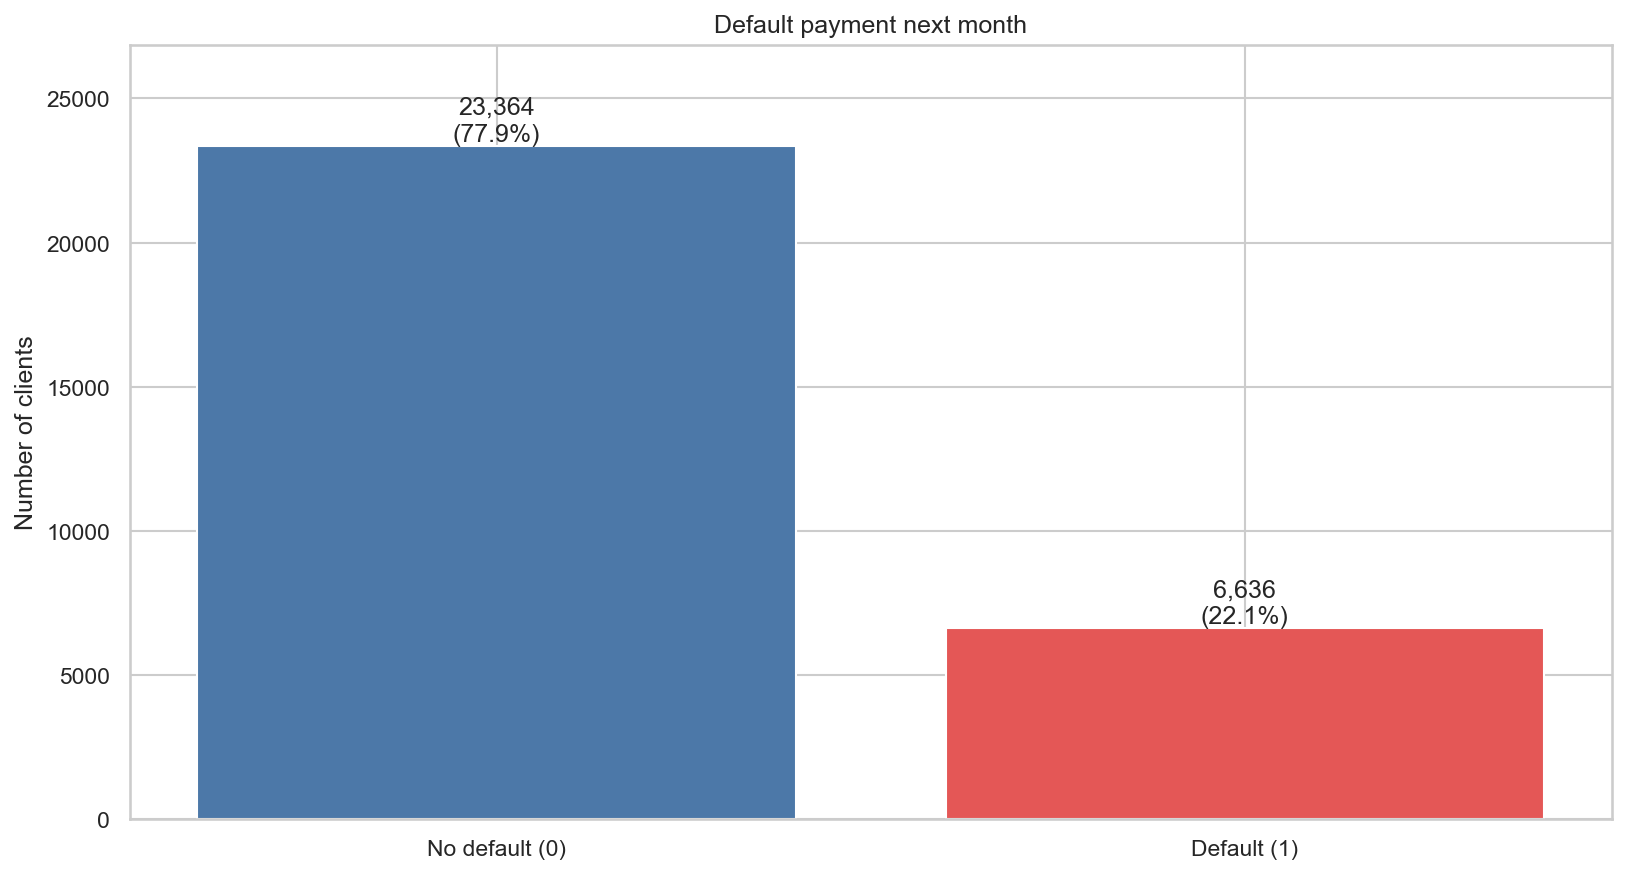

In [14]:
from IPython.display import Image, display
display(Image(filename=str(EDA_DIR / '01_target_distribution.png'), width=1000))

### 02. Default rate by demographic category

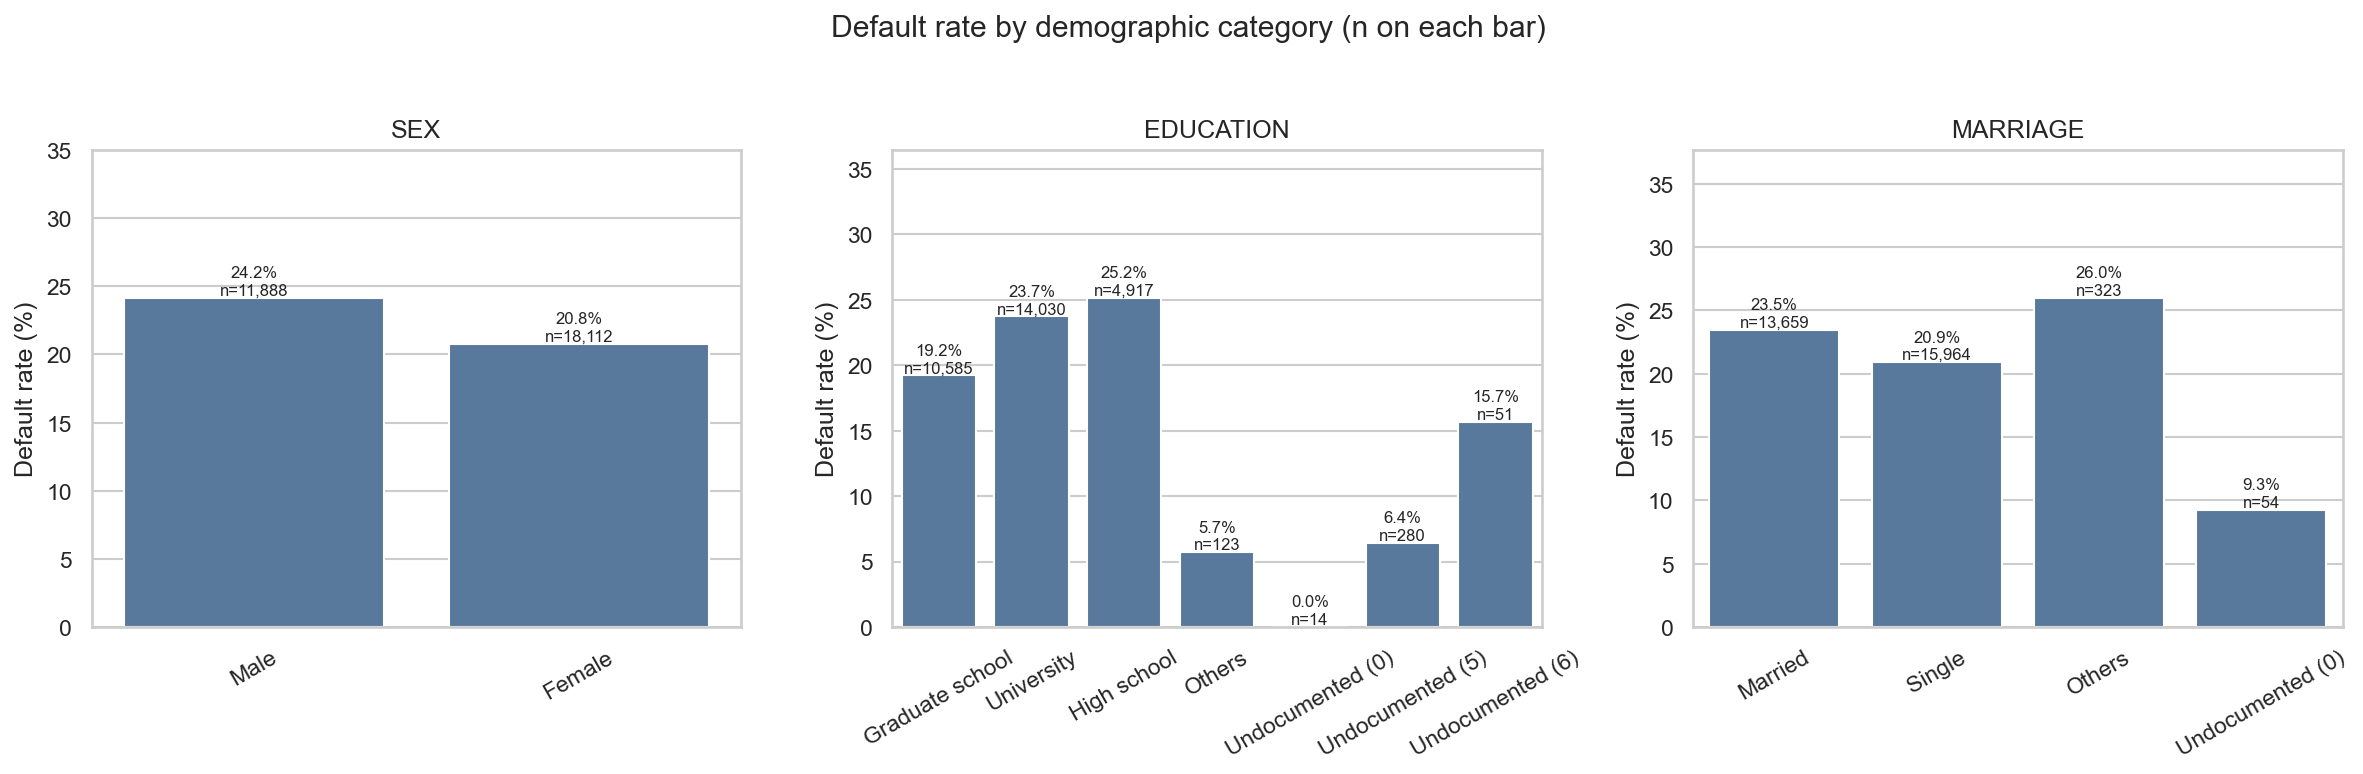

In [15]:
from IPython.display import Image, display
display(Image(filename=str(EDA_DIR / '02_default_rate_demographics.png'), width=1000))

### 03. Demographic counts by default status

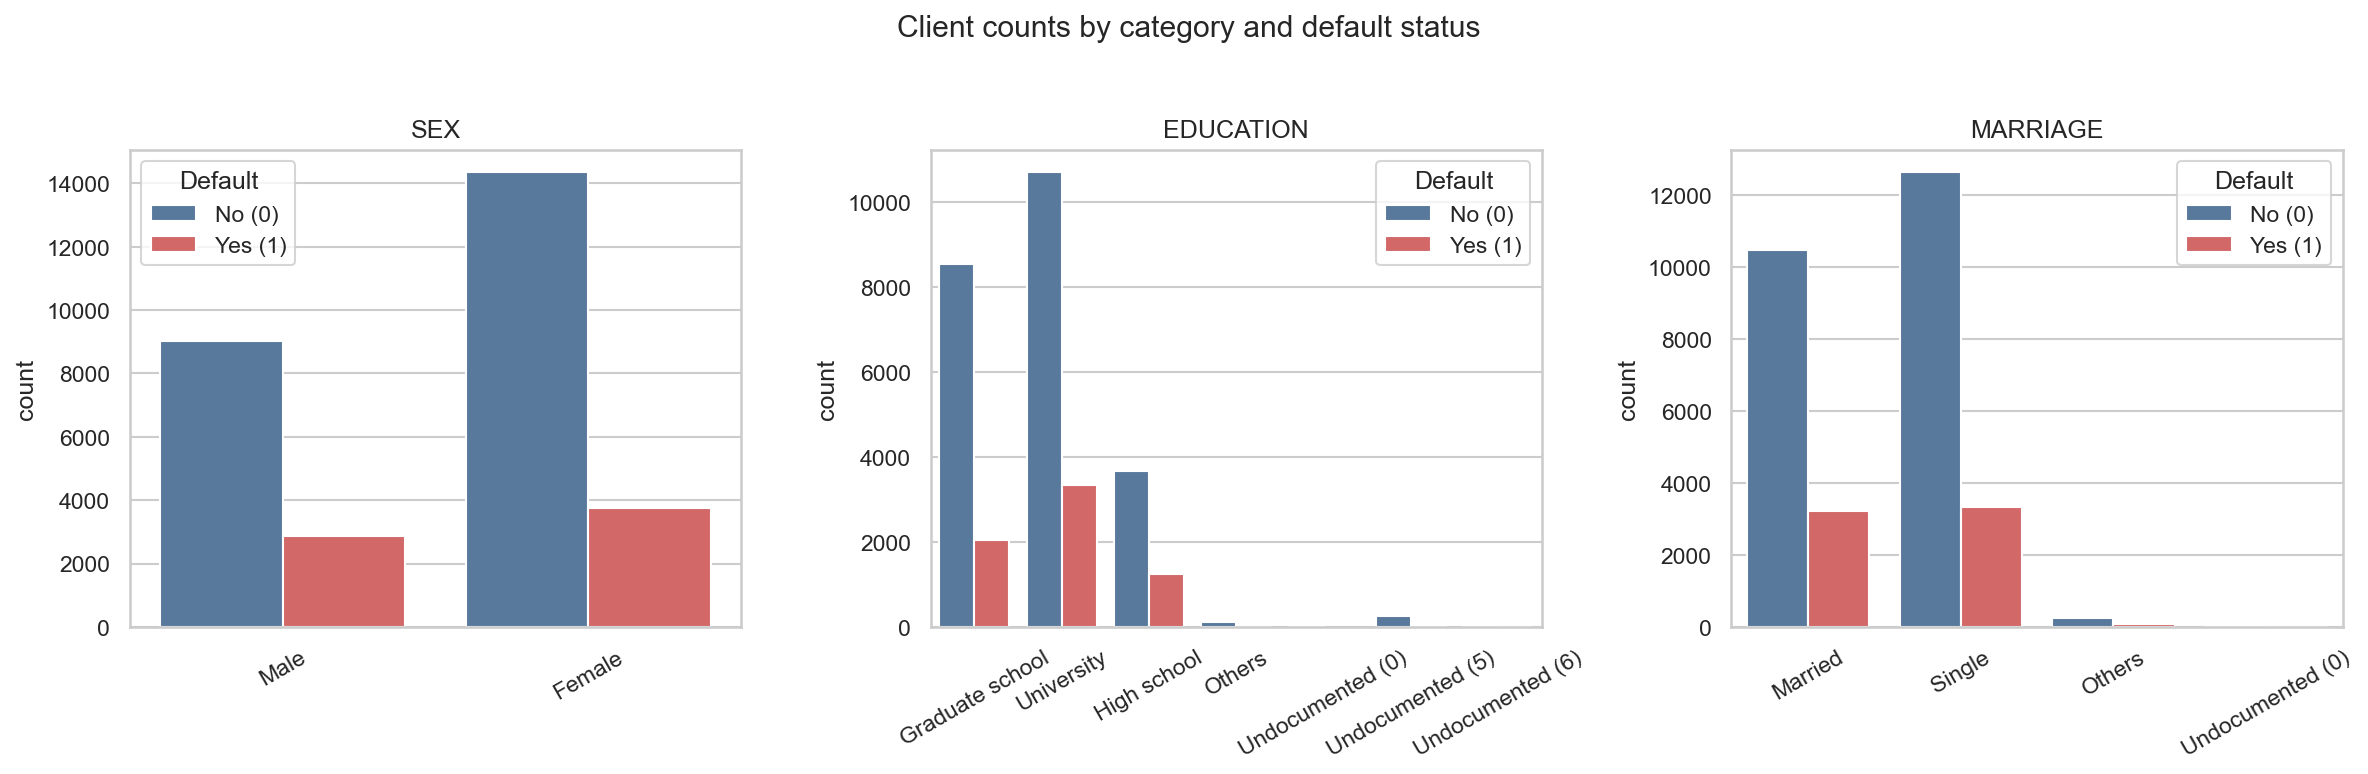

In [16]:
from IPython.display import Image, display
display(Image(filename=str(EDA_DIR / '03_counts_demographics.png'), width=1000))

### 04. Age and credit-limit distributions

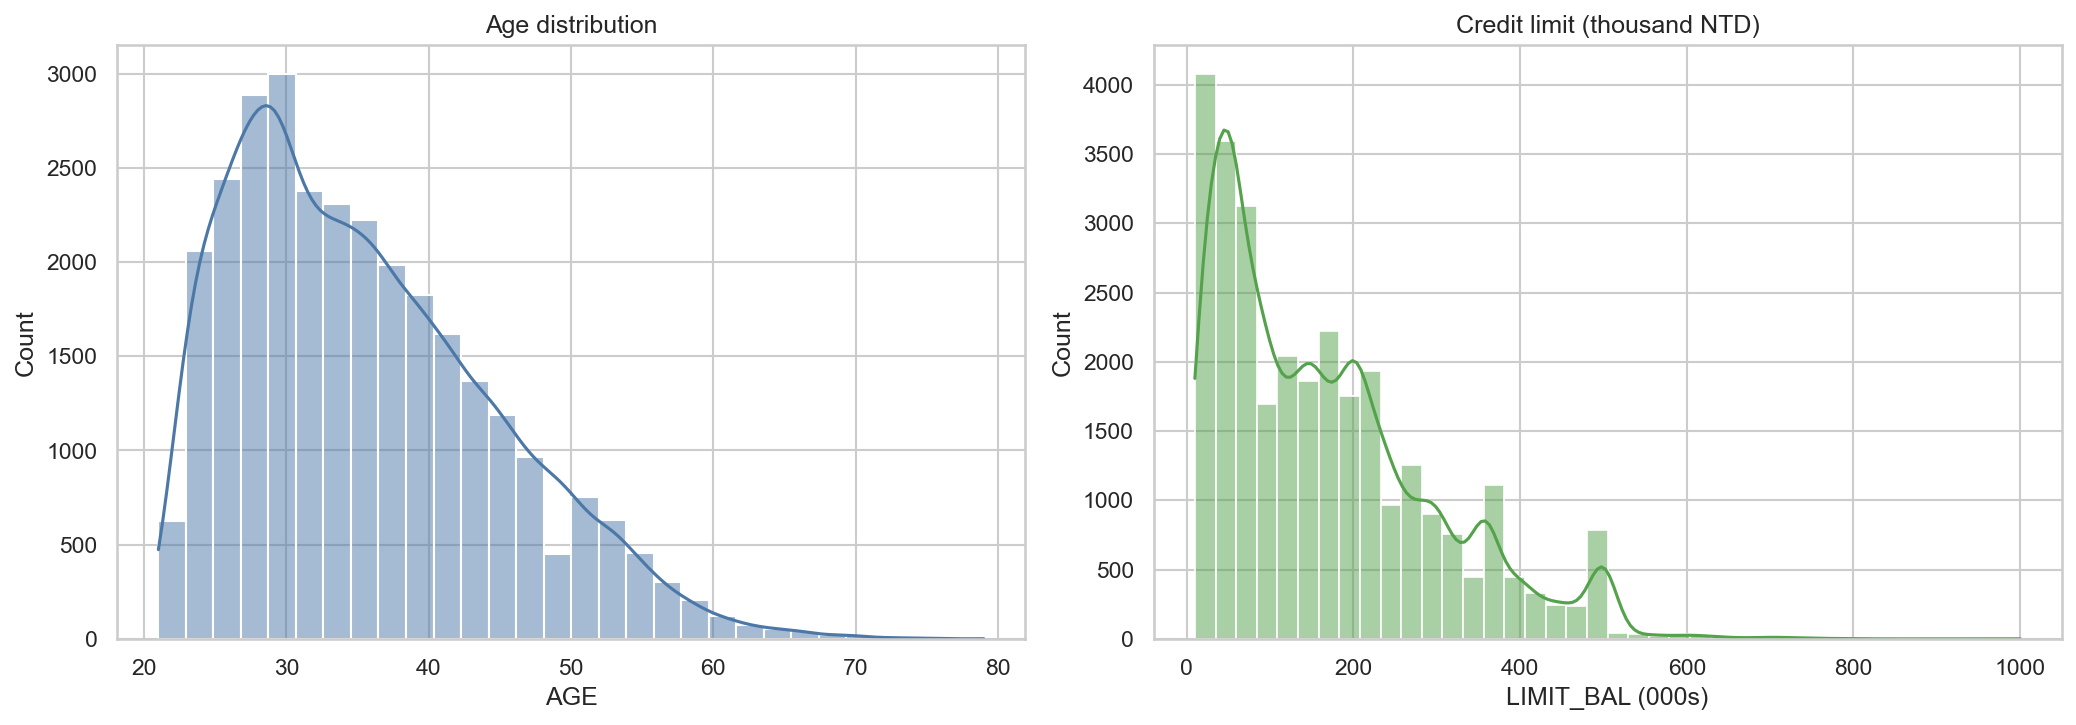

In [17]:
from IPython.display import Image, display
display(Image(filename=str(EDA_DIR / '04_age_limit_hist.png'), width=1000))

### 05. Age and credit limit by default status

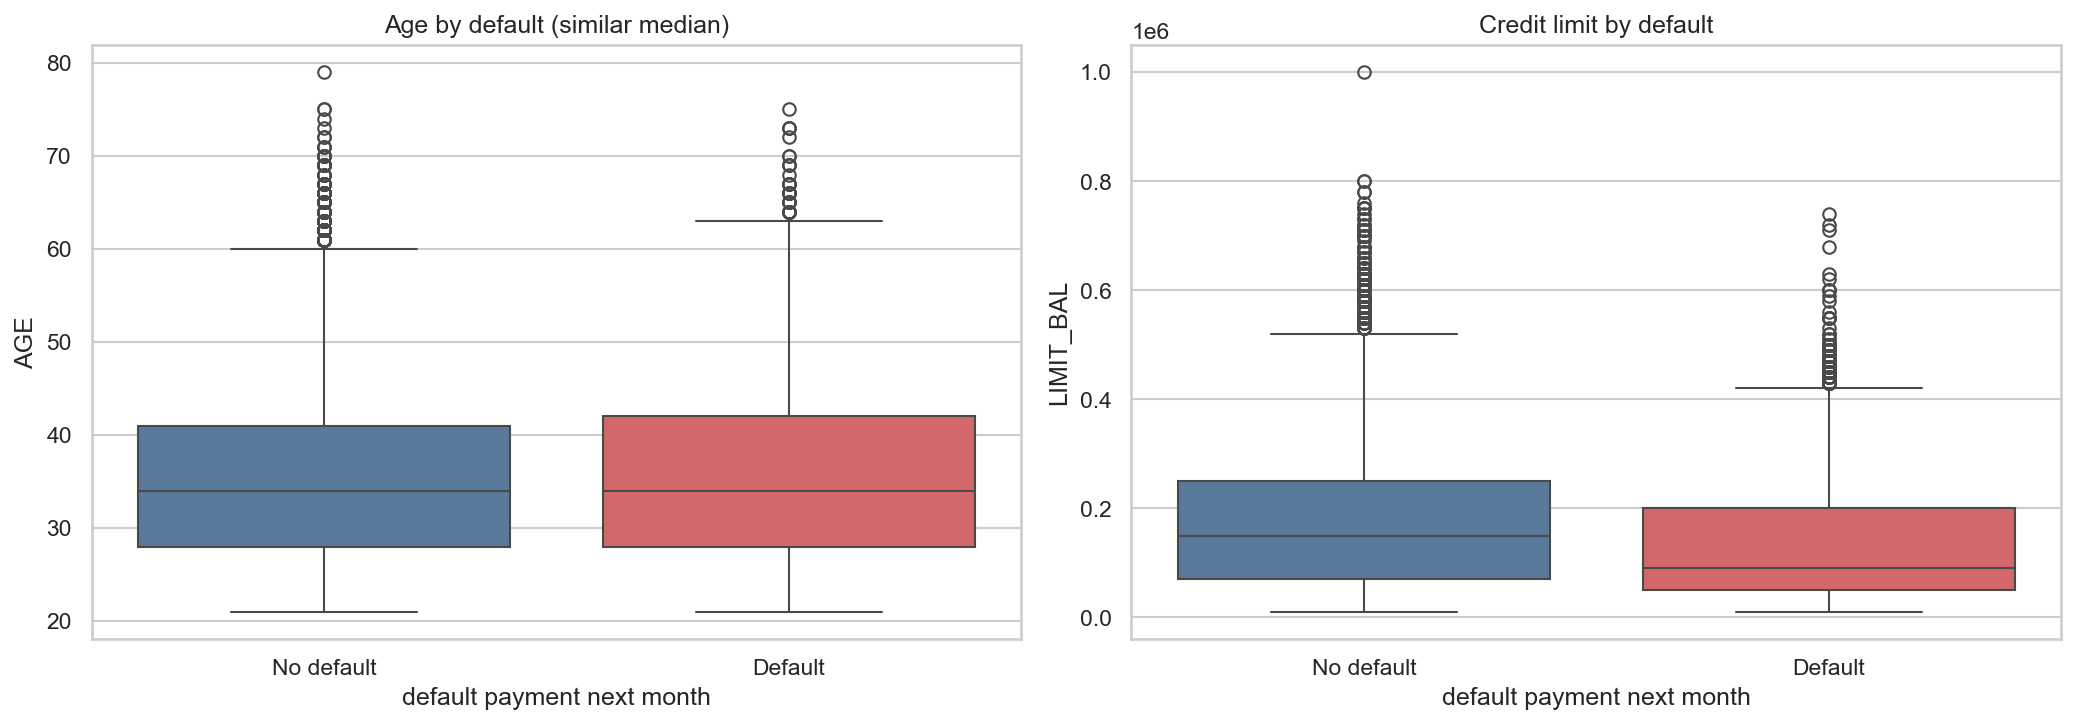

In [18]:
from IPython.display import Image, display
display(Image(filename=str(EDA_DIR / '05_age_limit_box_by_target.png'), width=1000))

### 06. Default rate by repayment status

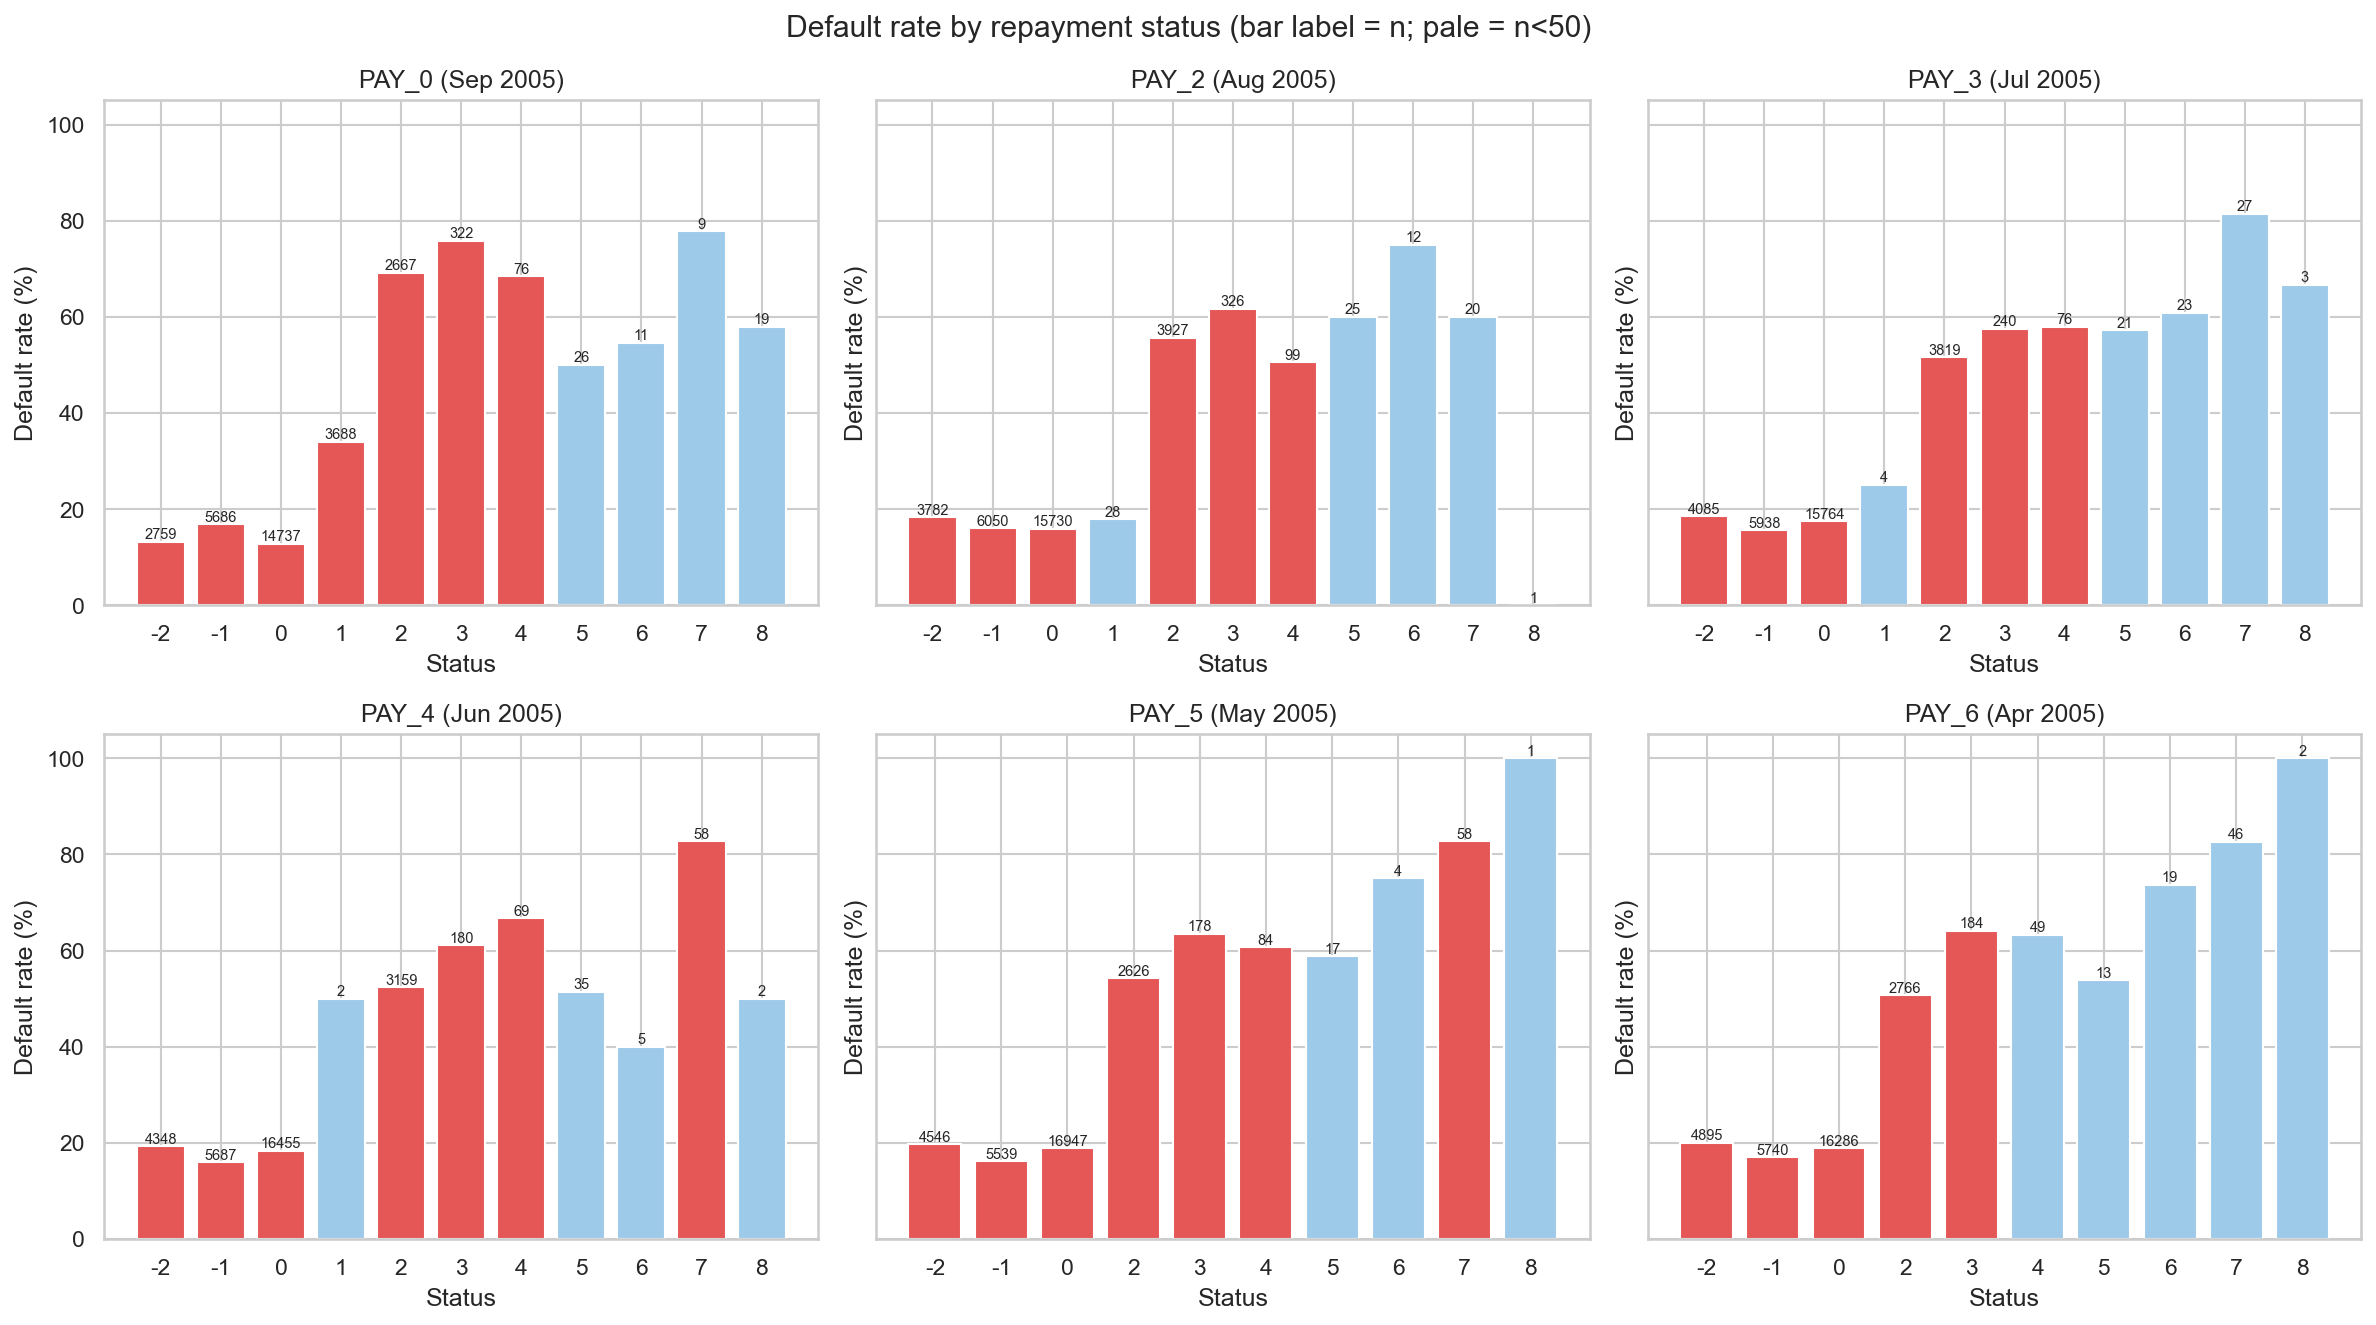

In [19]:
from IPython.display import Image, display
display(Image(filename=str(EDA_DIR / '06_default_rate_by_pay_status.png'), width=1000))

### 07. Repayment-status counts across months

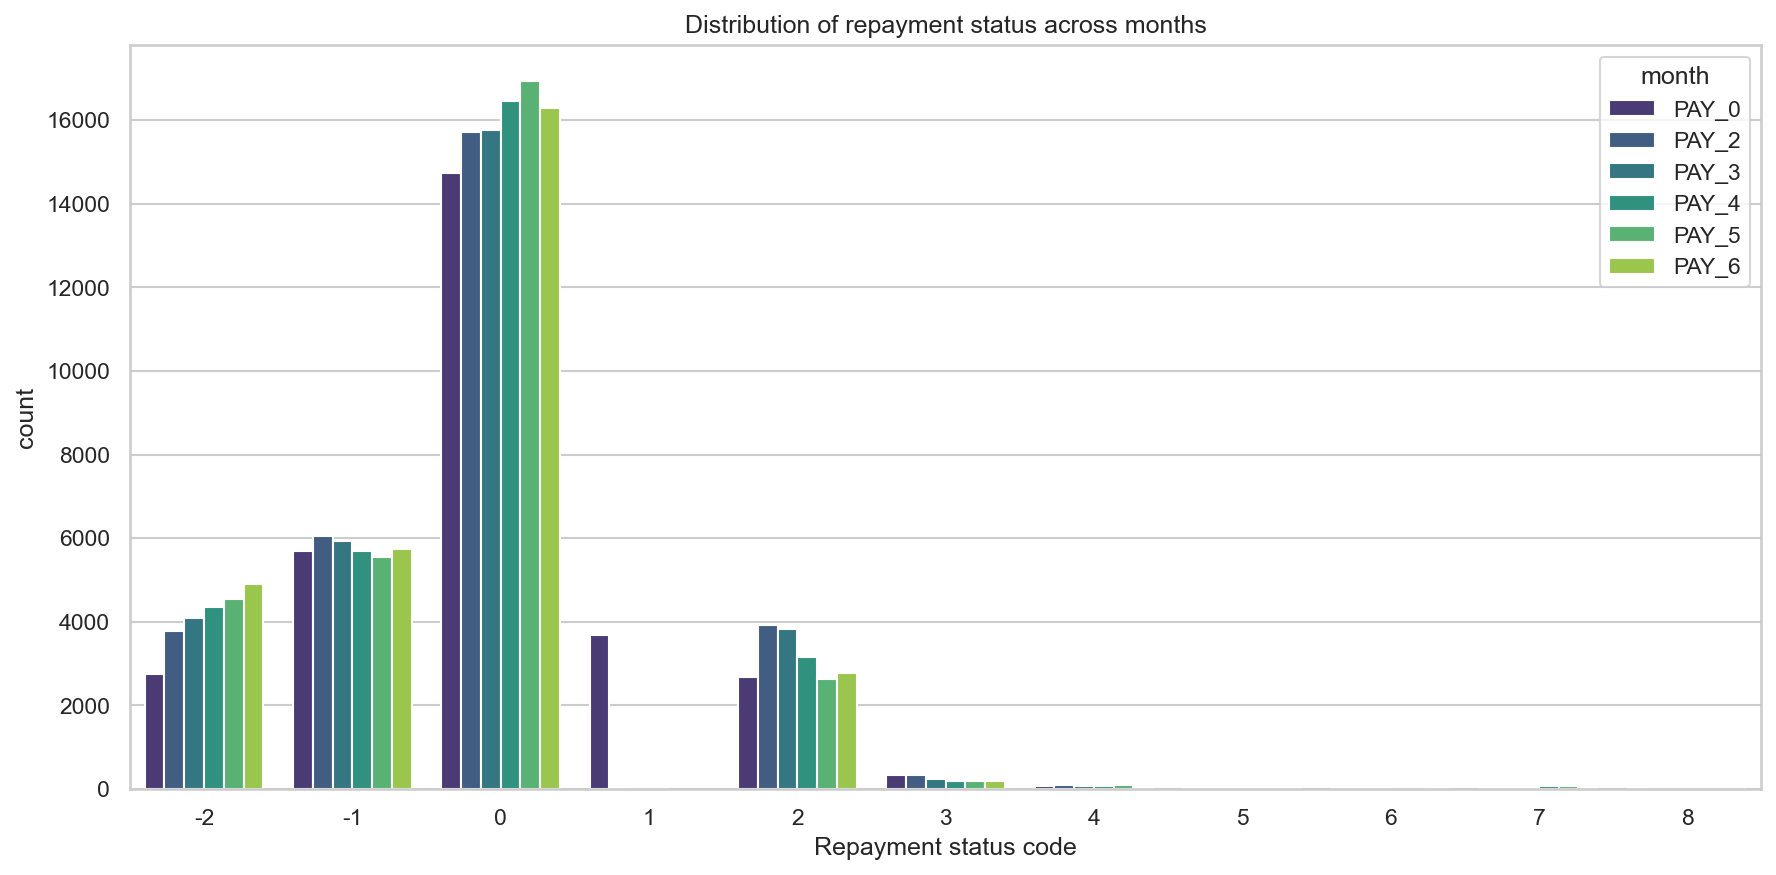

In [20]:
from IPython.display import Image, display
display(Image(filename=str(EDA_DIR / '07_pay_status_counts.png'), width=1000))

### 08. Bill-amount distributions

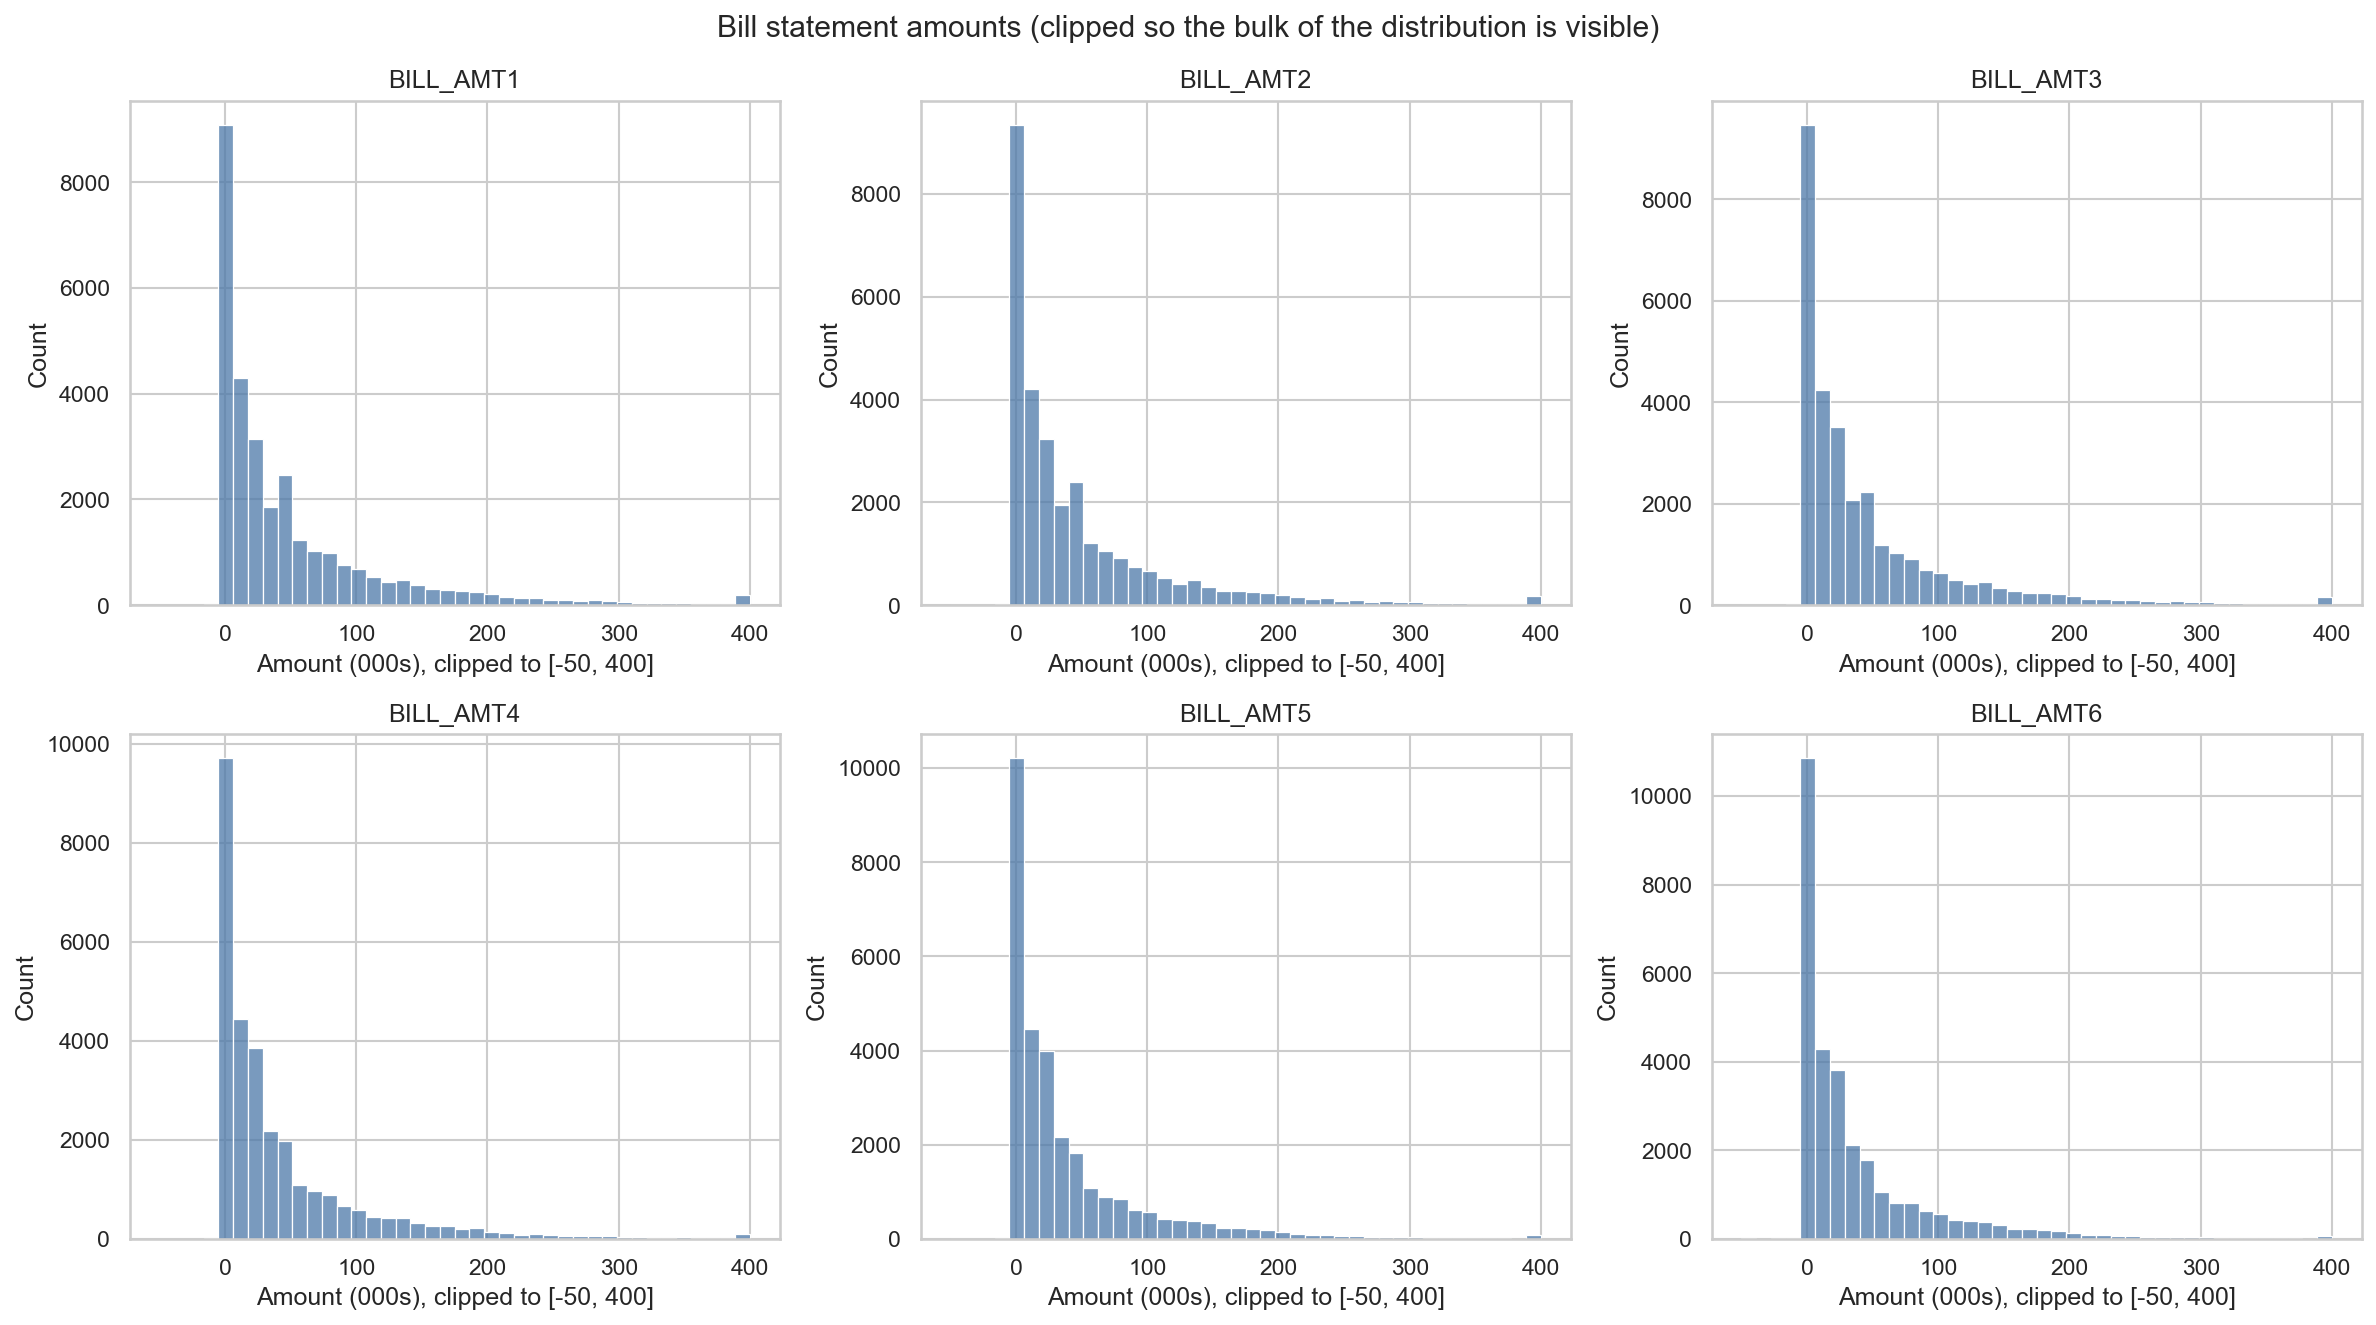

In [21]:
from IPython.display import Image, display
display(Image(filename=str(EDA_DIR / '08_bill_amount_hist.png'), width=1000))

### 09. Payment-amount distributions

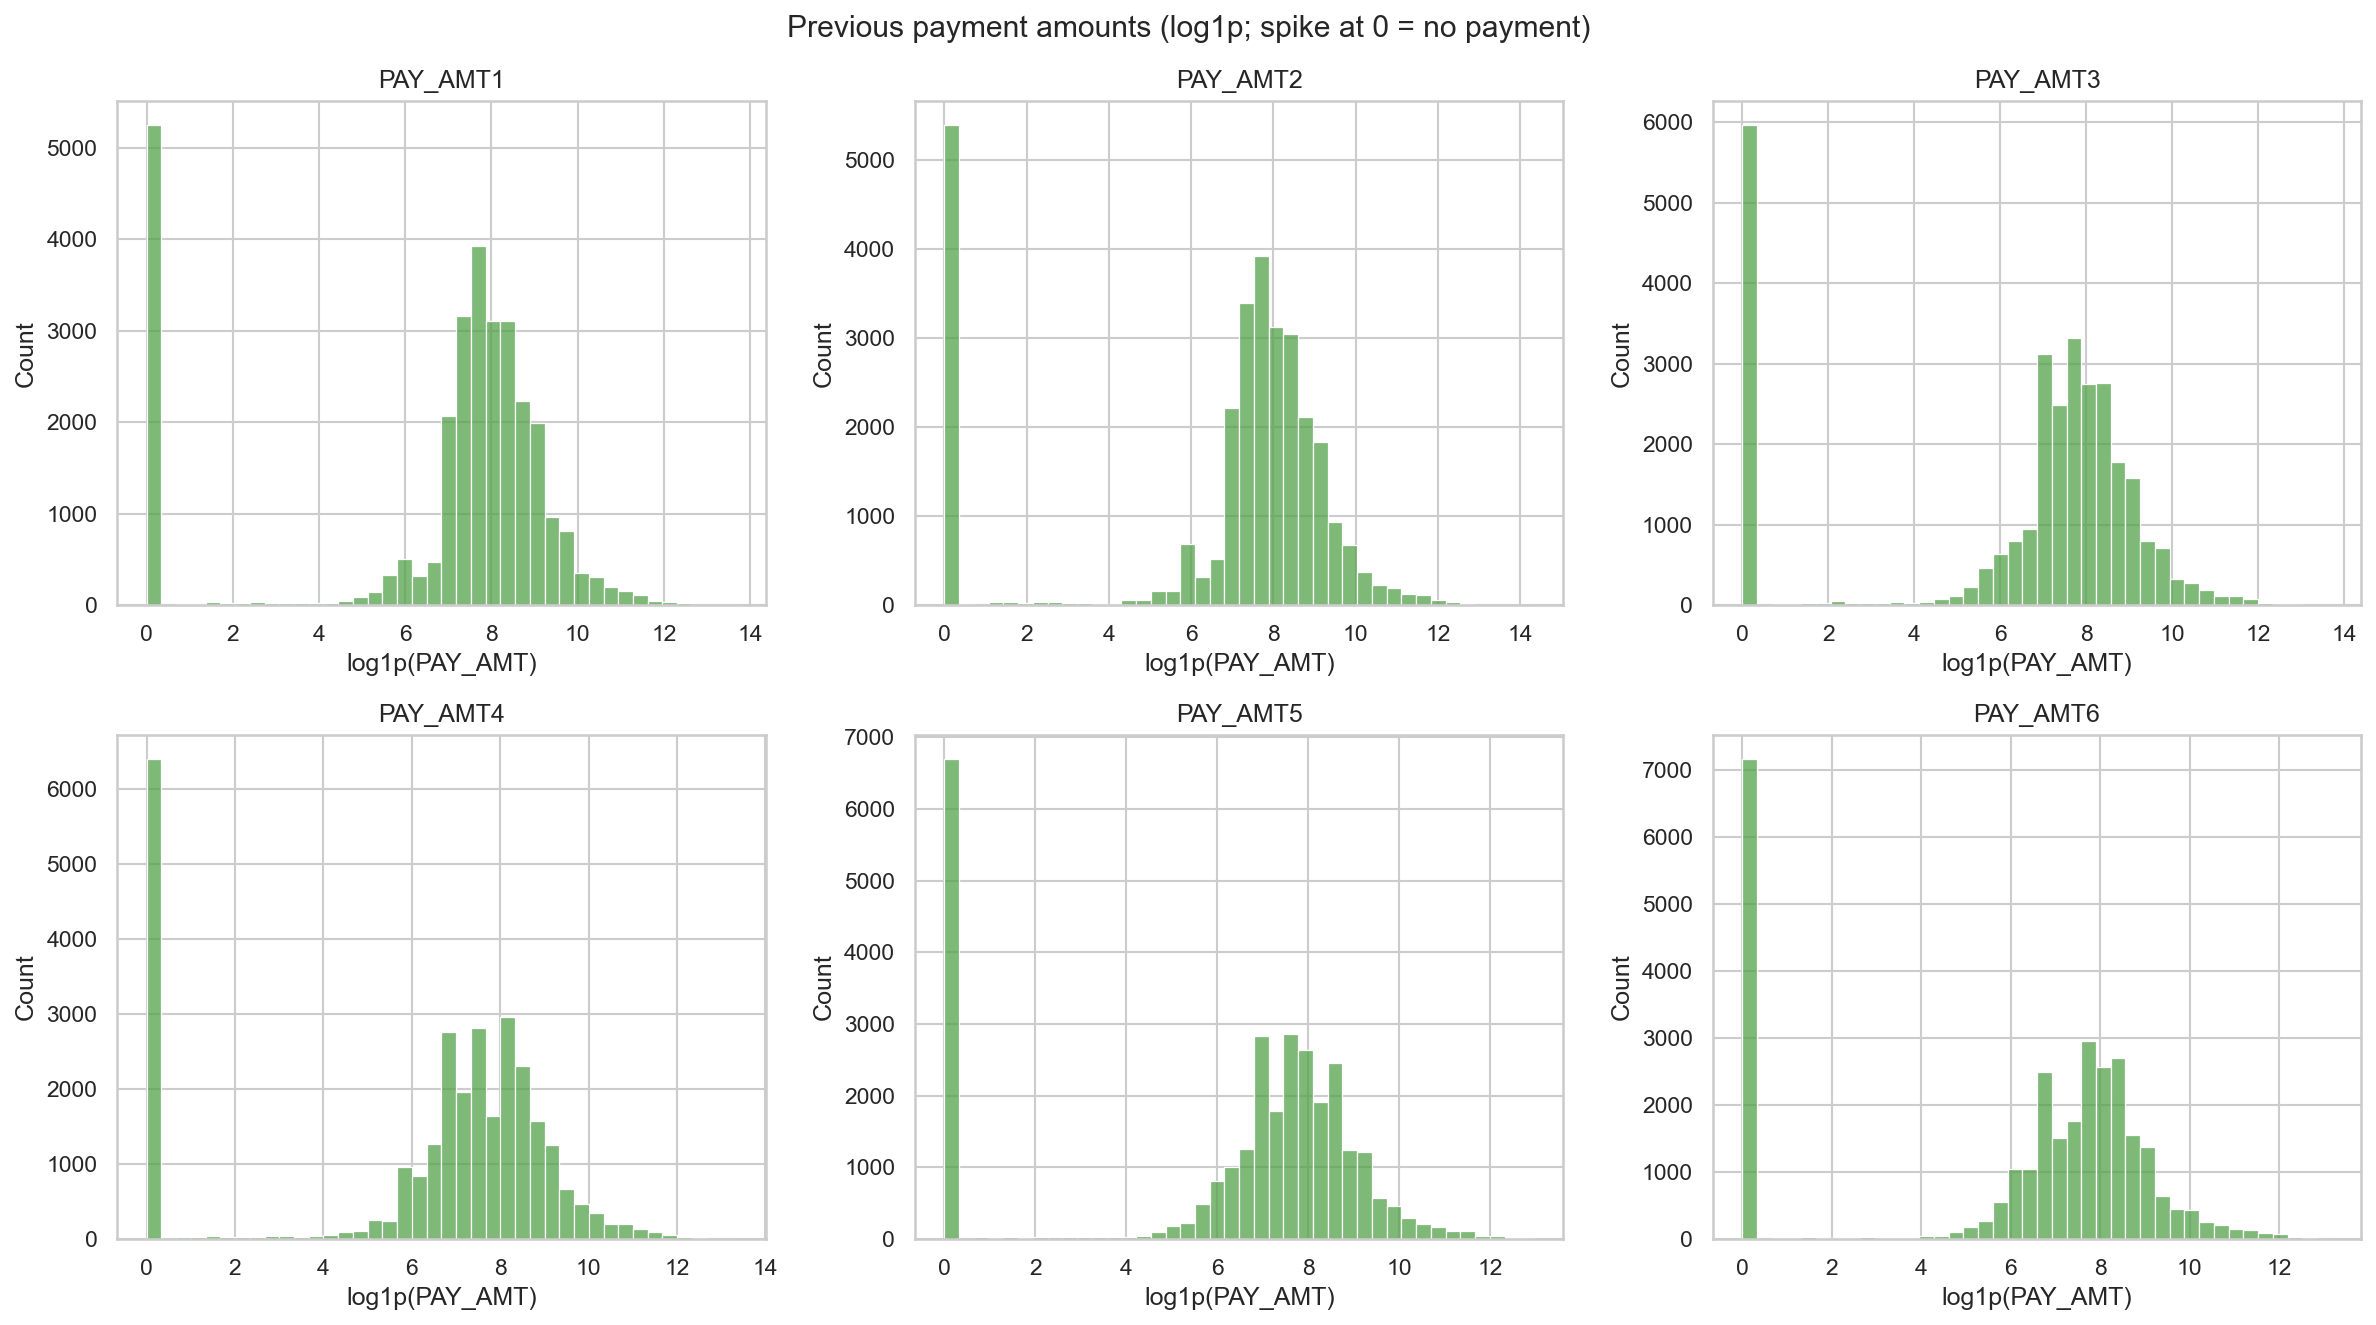

In [22]:
from IPython.display import Image, display
display(Image(filename=str(EDA_DIR / '09_pay_amount_log_hist.png'), width=1000))

### 10. Derived features by default status

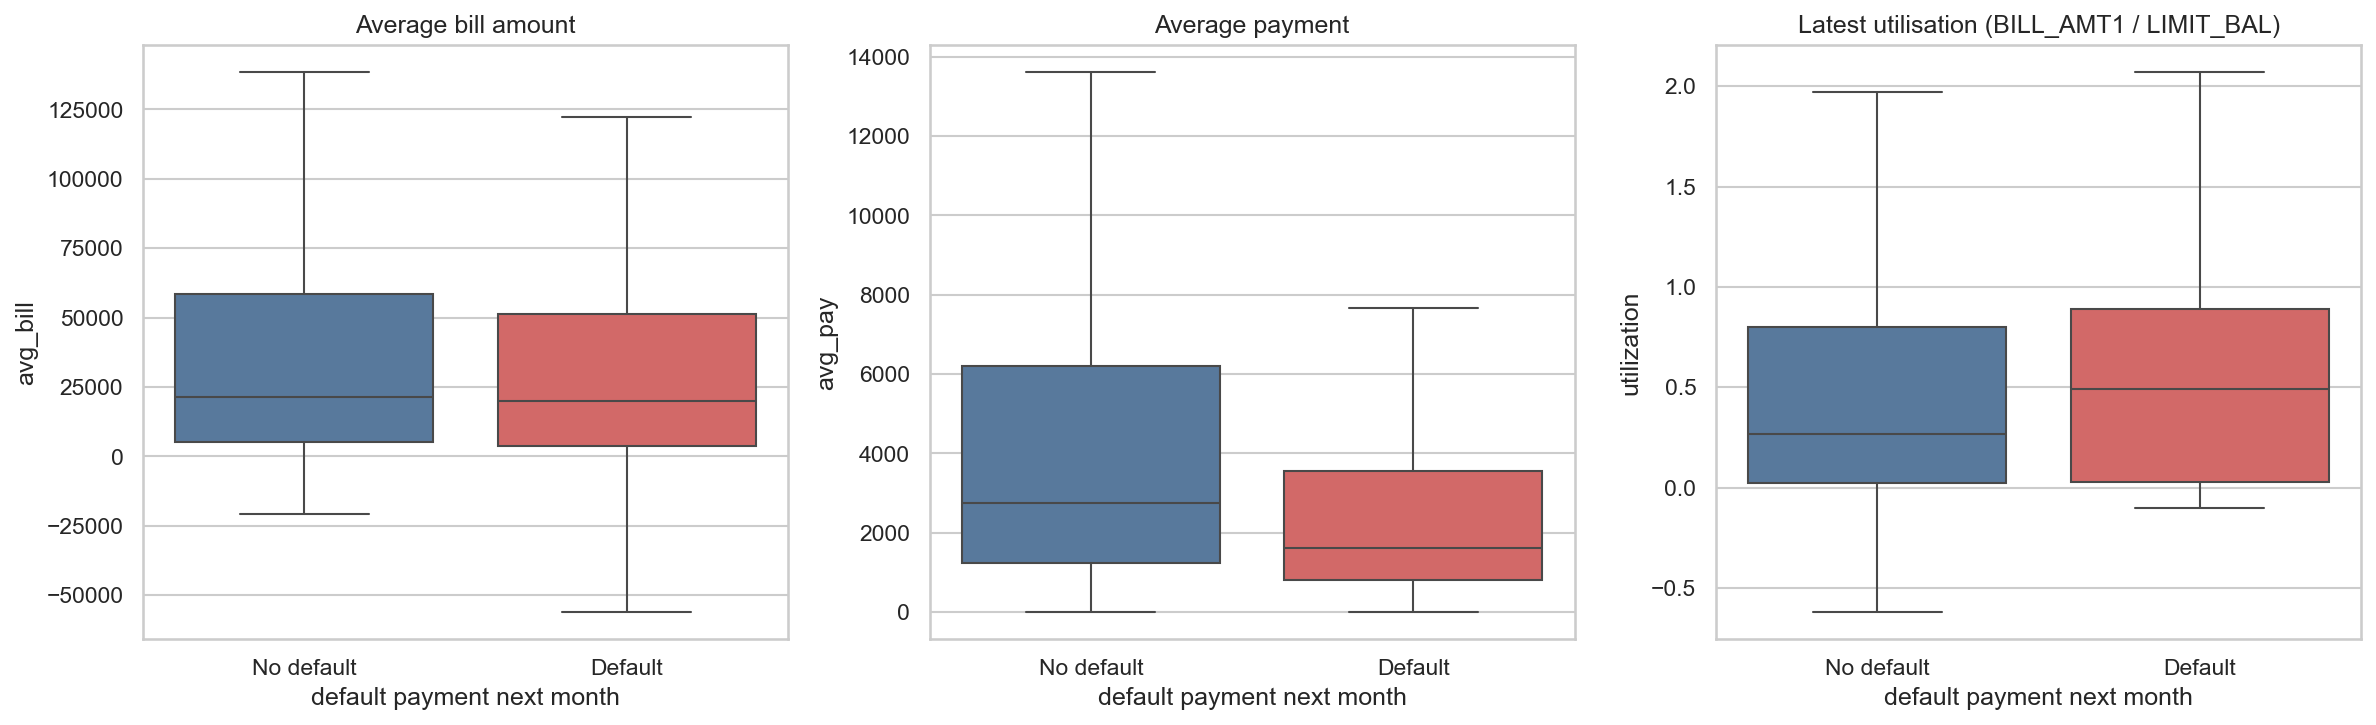

In [23]:
from IPython.display import Image, display
display(Image(filename=str(EDA_DIR / '10_derived_features_by_target.png'), width=1000))

### 11. Feature correlations with default

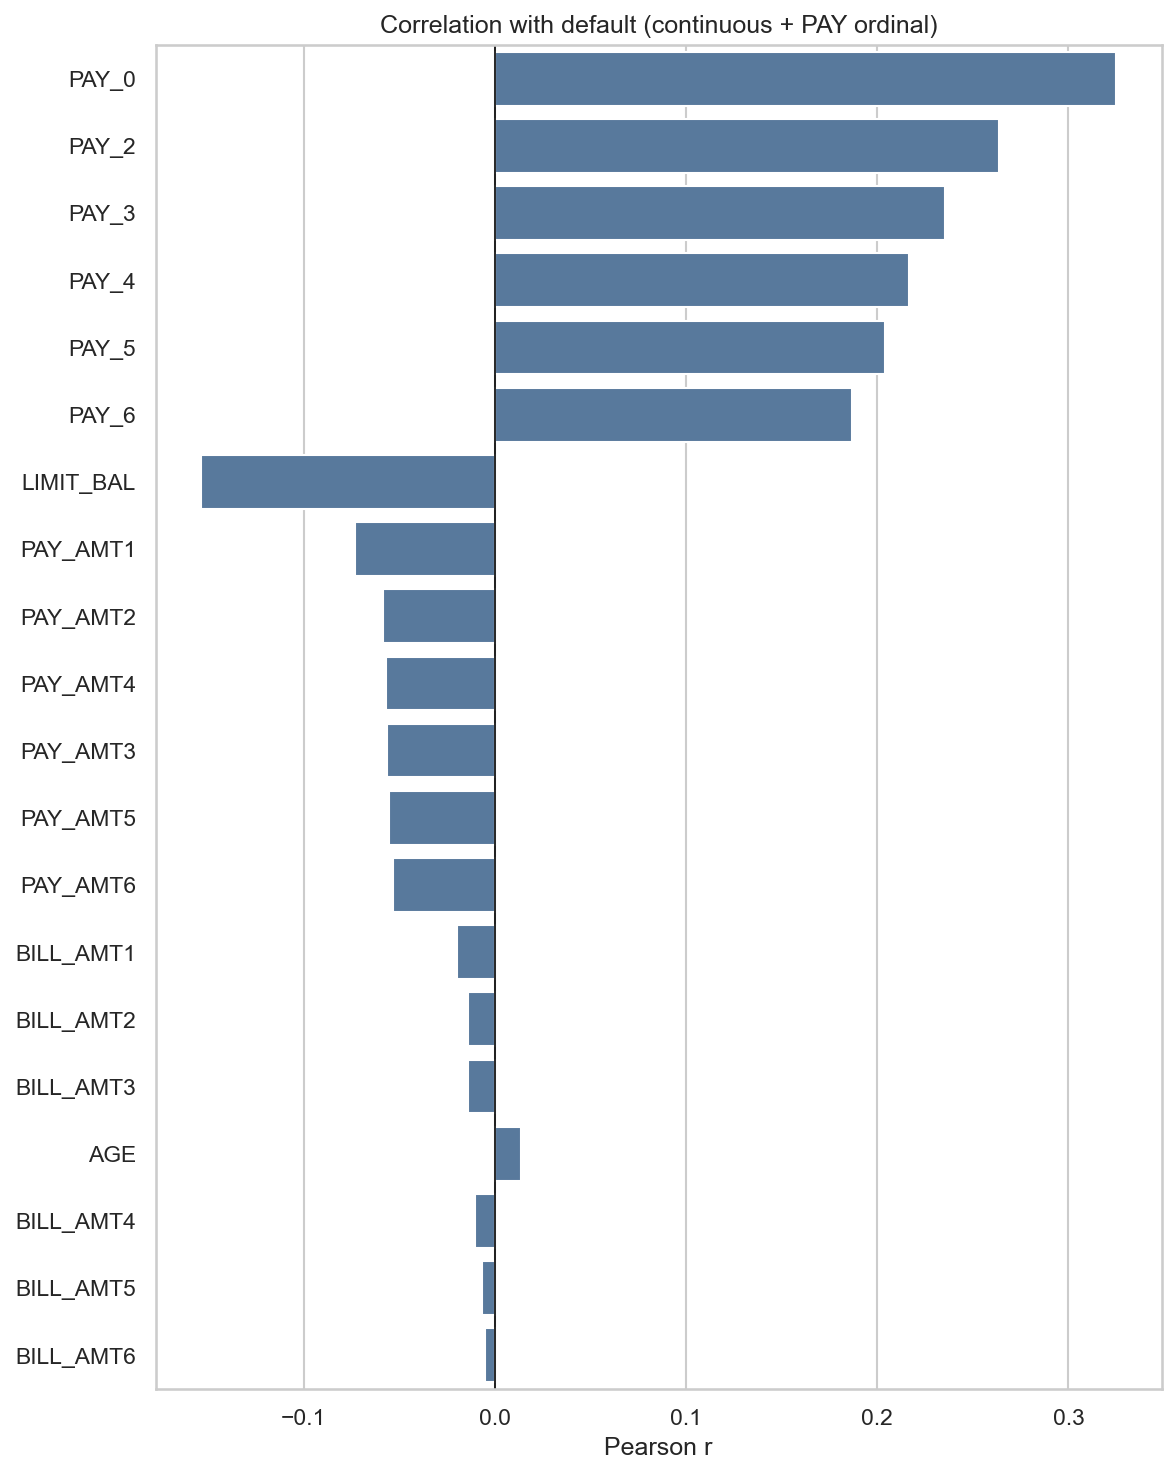

In [24]:
from IPython.display import Image, display
display(Image(filename=str(EDA_DIR / '11_target_correlations.png'), width=1000))

### 12. Correlation heatmap

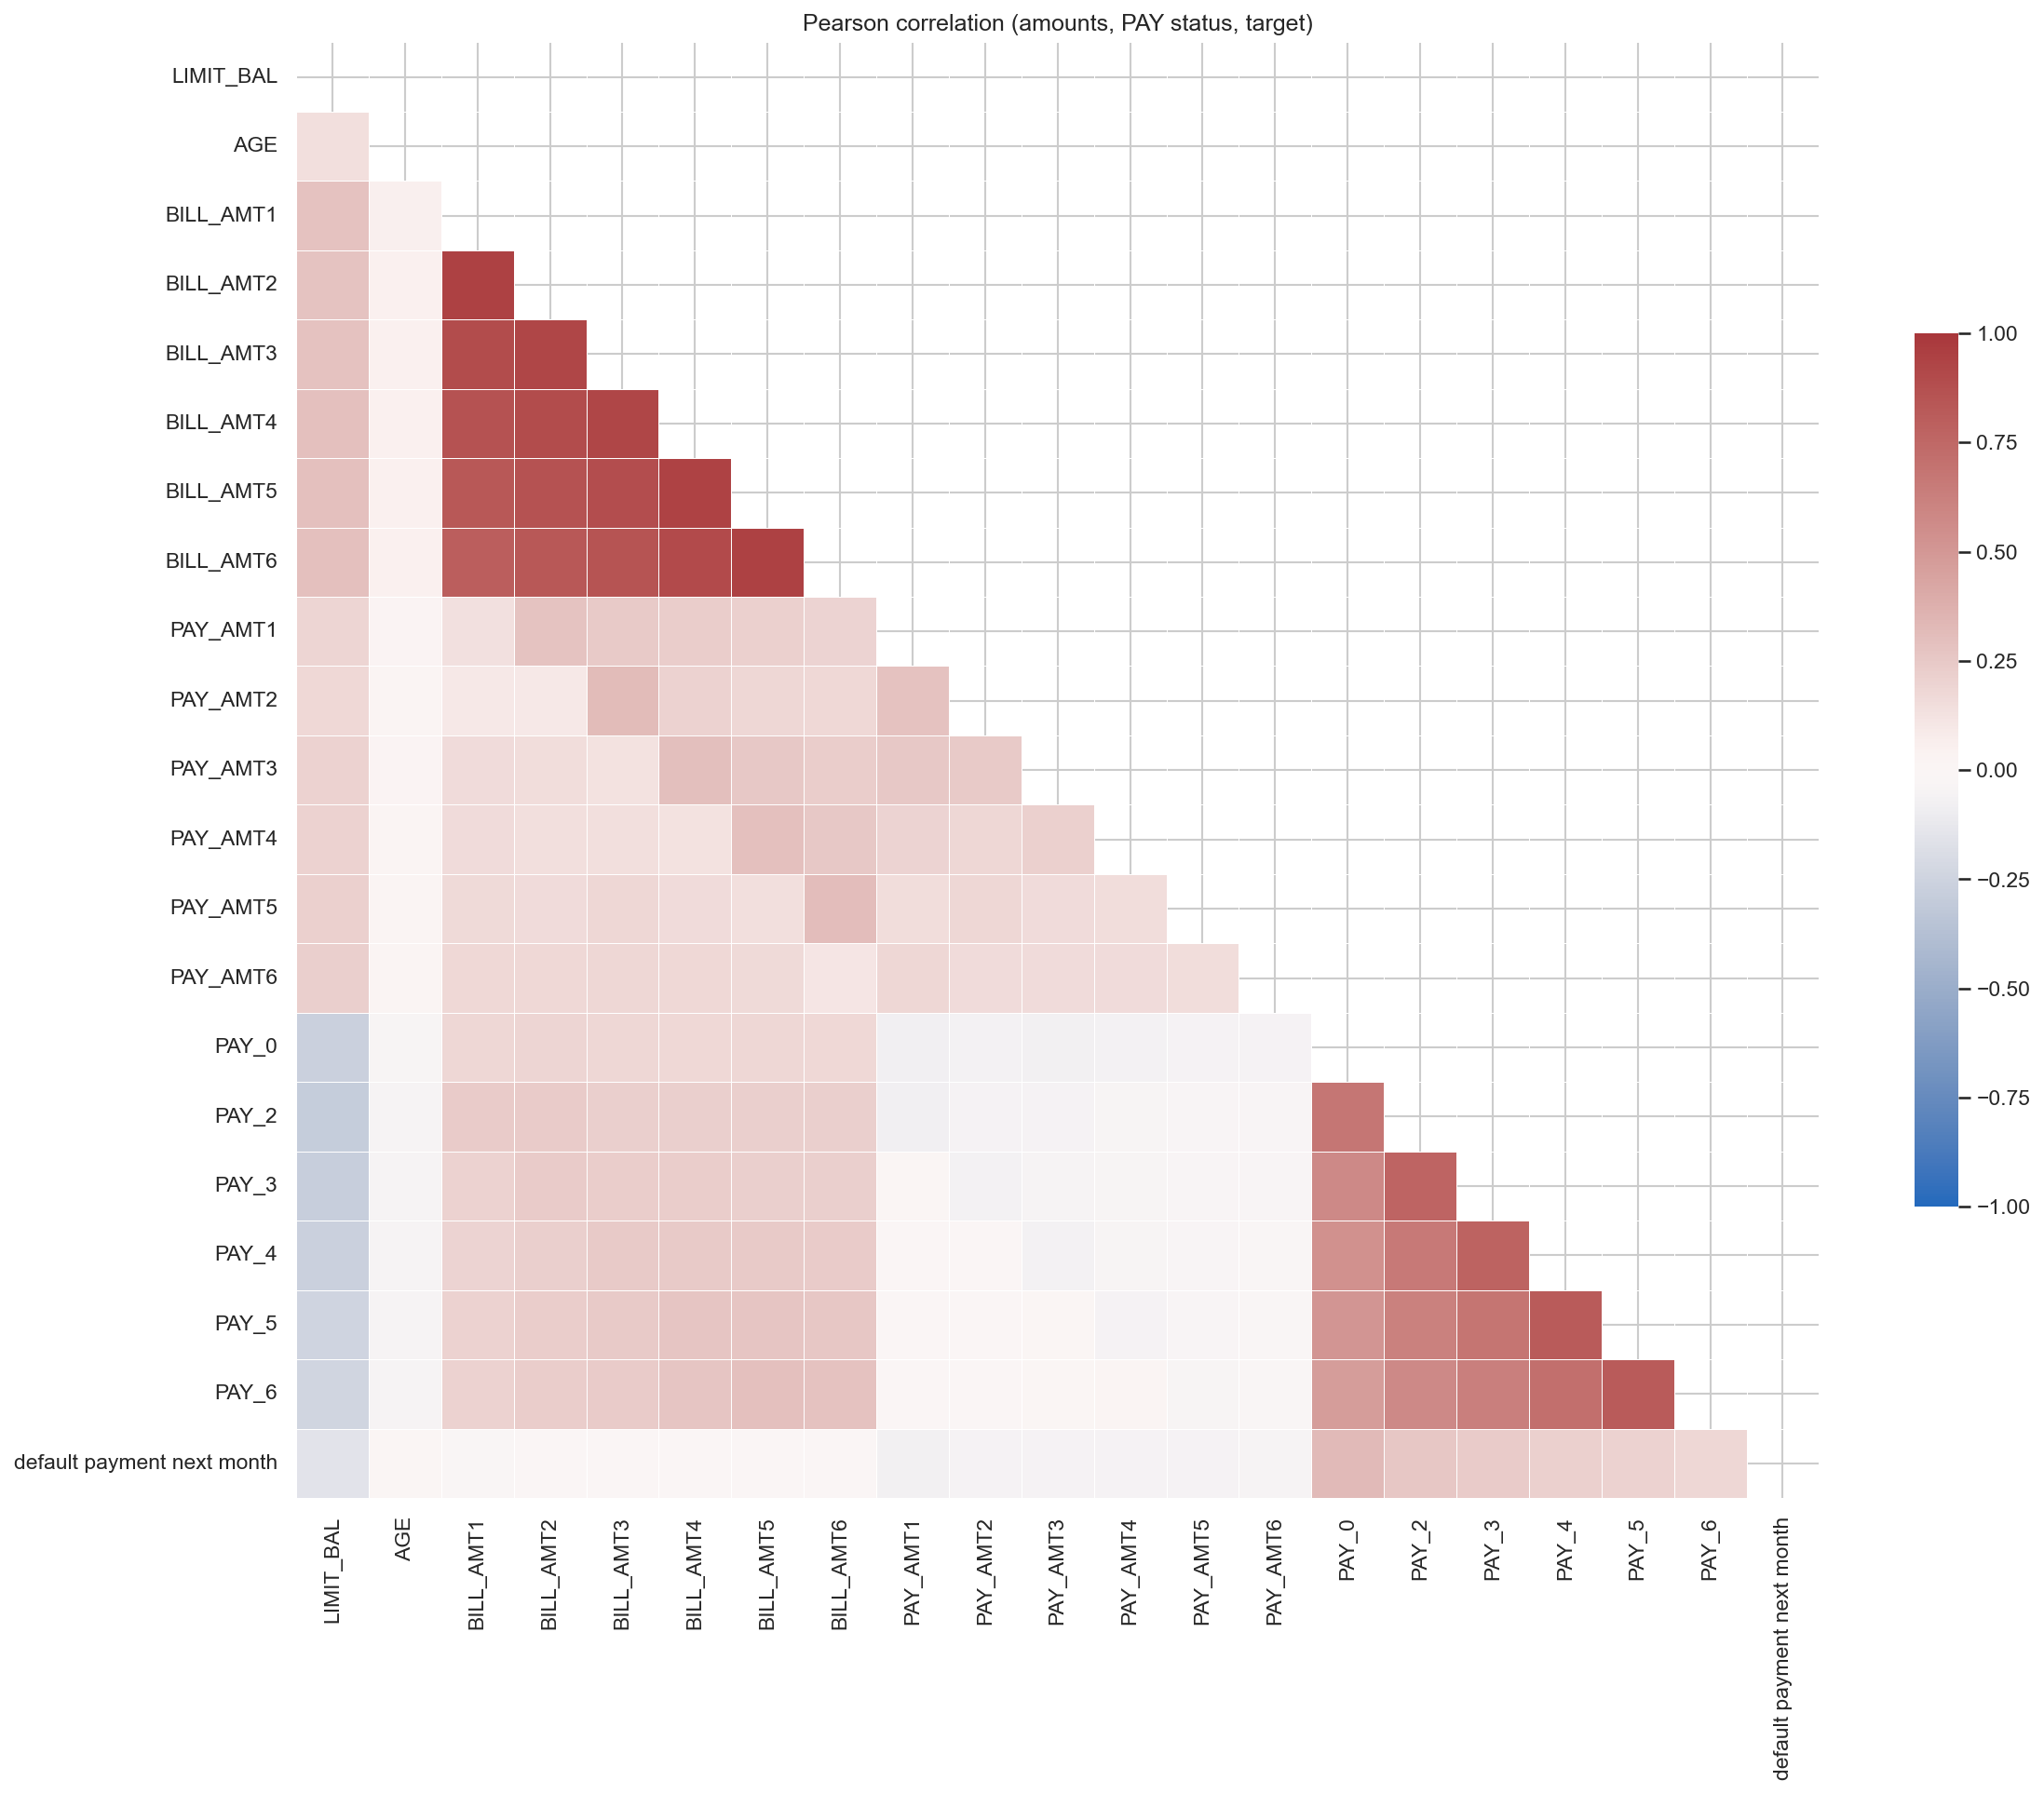

In [25]:
from IPython.display import Image, display
display(Image(filename=str(EDA_DIR / '12_correlation_heatmap.png'), width=1000))

### 13. Default rate by age and credit-limit group

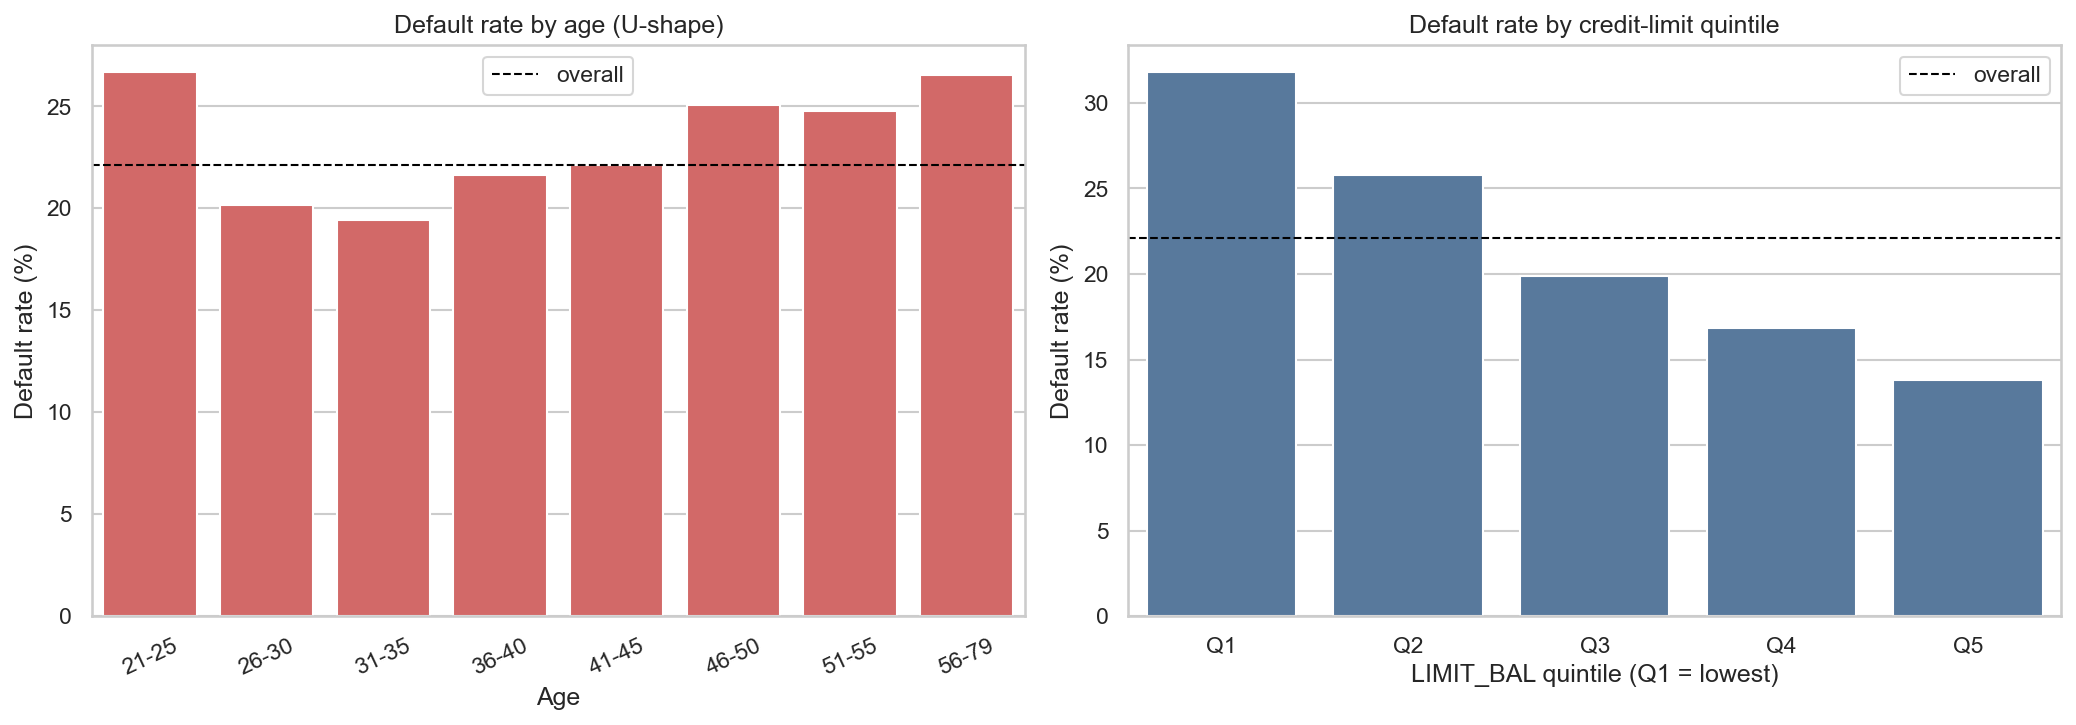

In [26]:
from IPython.display import Image, display
display(Image(filename=str(EDA_DIR / '13_age_limit_default_rates.png'), width=1000))

### EDA interpretation

The target is imbalanced: approximately 22% of clients default. Recent repayment status, especially `PAY_0`, is the strongest visible signal. Credit limit, repayment behaviour, and payment amounts also show useful relationships with default. These findings motivate class-aware model evaluation and the use of recall, F1-score, ROC-AUC, and average precision in addition to accuracy.

## 5. Cleaning, feature engineering, and preprocessing

The following cell runs the complete authoritative preparation pipeline from `eda_preprocess.py`. It:

- Removes duplicate feature profiles before the split.
- Recodes undocumented education and marriage values as `Others`.
- Groups rare repayment codes above 4 into 4+.
- Creates `utilization`, `avg_pay`, and `inactive` features.
- Performs a stratified 80/20 split.
- Fits one-hot encoding on training data only.
- Fits scaling on training data only.
- Saves processed data, fitted transformers, and summary files.

In [27]:
prep.run_preprocess(raw_df)


11. Clean (before split)
Dropped duplicate extras : 35
Rows after dedup         : 29965
EDUCATION 0/5/6 -> Others: 345
MARRIAGE 0 -> Others     : 54
PAY codes > 4 capped to 4:
  PAY_0: 65
  PAY_2: 58
  PAY_3: 74
  PAY_4: 100
  PAY_5: 80
  PAY_6: 80
Inactive flag            : 765
utilisation > 1          : 2115
Default rate after clean : 22.13%

Category counts after recode:
  SEX: {'Female': 18091, 'Male': 11874}
  EDUCATION: {'University': 14019, 'Graduate school': 10563, 'High school': 4915, 'Others': 468}
  MARRIAGE: {'Single': 15945, 'Married': 13643, 'Others': 377}
PAY_0 counts after cap:
  {-2: 2750, -1: 5682, 0: 14737, 1: 3667, 2: 2666, 3: 322, 4: 141}

12. Stratified train/test split
Train: 23,972  default=22.13%
Test : 5,993  default=22.13%
Test size=0.2, random_state=42, stratify=default

13. One-hot encode SEX / EDUCATION / MARRIAGE (fit on train)
Dummy columns (drop first): ['SEX_Female', 'EDUCATION_University', 'EDUCATION_High school', 'EDUCATION_Others', 'MARRIAGE_Single

  saved train.csv  shape=(23972, 30)
  saved test.csv  shape=(5993, 30)


  saved train_scaled.csv  shape=(23972, 30)
  saved test_scaled.csv  shape=(5993, 30)
  saved encoder.joblib, scaler.joblib, feature_names.json, split_ids.csv

Preprocessing summary
Raw rows                         : 30,000
Duplicate extras dropped         : 35
Rows after clean                 : 29,965
EDUCATION 0/5/6 -> Others        : 345
MARRIAGE 0 -> Others             : 54
Train / test                     : 23,972 / 5,993
Train default rate               : 22.13%
Test default rate                : 22.13%
Features (unscaled, one-hot)     : 29

Use train.csv + test.csv for Decision Tree and Random Forest.
Use train_scaled.csv + test_scaled.csv for ANN and Gaussian Naive Bayes.
Do not fit scalers or encoders again on the test set.

Processed files saved to: /Users/maxhoang/Desktop/IT Codefair/ASS3/PRT565-Assignment-3/processed


In [28]:
preprocessing_summary = json.loads((PROCESSED_DIR / "preprocess_summary.json").read_text())
display(pd.Series({
    "Raw rows": preprocessing_summary["n_raw"],
    "Duplicate extras dropped": preprocessing_summary["n_duplicate_extras_dropped"],
    "Rows after cleaning": preprocessing_summary["n_after_dedup"],
    "Training rows": preprocessing_summary["n_train"],
    "Test rows": preprocessing_summary["n_test"],
    "Training default rate": f"{100 * preprocessing_summary['train_default_rate']:.2f}%",
    "Test default rate": f"{100 * preprocessing_summary['test_default_rate']:.2f}%",
    "Model features": preprocessing_summary["n_features"],
}, name="Value").to_frame())

,Value
Raw rows,30000
Duplicate extras dropped,35
Rows after cleaning,29965
Training rows,23972
Test rows,5993
Training default rate,22.13%
Test default rate,22.13%
Model features,29


## 6. Load the prepared modelling data

Tree models use the one-hot encoded, unscaled data. Gaussian Naive Bayes and the MLP use the scaled data. All models use the same train/test client split and the same target labels.

In [29]:
train_df = pd.read_csv(PROCESSED_DIR / "train.csv")
test_df = pd.read_csv(PROCESSED_DIR / "test.csv")
train_scaled_df = pd.read_csv(PROCESSED_DIR / "train_scaled.csv")
test_scaled_df = pd.read_csv(PROCESSED_DIR / "test_scaled.csv")

X_train = train_df.drop(columns=[TARGET])
X_test = test_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
y_test = test_df[TARGET]
X_train_scaled = train_scaled_df.drop(columns=[TARGET])
X_test_scaled = test_scaled_df.drop(columns=[TARGET])

if not y_train.equals(train_scaled_df[TARGET]) or not y_test.equals(test_scaled_df[TARGET]):
    raise ValueError("Scaled and unscaled targets are not aligned")

print(f"Unscaled training data: {X_train.shape}")
print(f"Unscaled test data: {X_test.shape}")
print(f"Default rate: train={y_train.mean():.2%}; test={y_test.mean():.2%}")

Unscaled training data: (23972, 29)
Unscaled test data: (5993, 29)
Default rate: train=22.13%; test=22.13%


## 7. Evaluation helper and majority-class baseline

Accuracy is included for completeness, but it is not sufficient for this imbalanced target. Precision, recall, F1-score, ROC-AUC, and average precision are also reported for the default class.

In [30]:
def evaluate_model(name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]
    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Recall": recall_score(y_eval, y_pred, zero_division=0),
        "F1-Score": f1_score(y_eval, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_eval, y_proba),
        "Average Precision": average_precision_score(y_eval, y_proba),
    }
    print(f"\n{name}")
    print(classification_report(y_eval, y_pred, target_names=CLASS_NAMES, digits=4))
    return result, y_pred, y_proba

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_result, _, baseline_proba = evaluate_model("Majority Baseline", baseline, X_test, y_test)
results = [baseline_result]
probabilities = {"Majority Baseline": baseline_proba}


Majority Baseline
              precision    recall  f1-score   support

  No Default     0.7787    1.0000    0.8756      4667
     Default     0.0000    0.0000    0.0000      1326

    accuracy                         0.7787      5993
   macro avg     0.3894    0.5000    0.4378      5993
weighted avg     0.6064    0.7787    0.6819      5993



/private/tmp/prt565-review-Wec28C/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/private/tmp/prt565-review-Wec28C/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/private/tmp/prt565-review-Wec28C/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

## 8. Decision Tree model

A grid search selects the tree depth, minimum leaf size, and split criterion using stratified five-fold cross-validation and F1-score.

In [31]:
dt_grid = {
    "max_depth": [4, 6, 8, 10, 12, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "criterion": ["gini", "entropy"],
}
dt_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    dt_grid,
    scoring="f1",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
)
dt_search.fit(X_train, y_train)
dt_model = dt_search.best_estimator_
print("Best parameters:", dt_search.best_params_)
print(f"Best CV F1-score: {dt_search.best_score_:.4f}")
dt_result, _, dt_proba = evaluate_model("Decision Tree", dt_model, X_test, y_test)
results.append(dt_result)
probabilities["Decision Tree"] = dt_proba

Best parameters: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 20}
Best CV F1-score: 0.5311

Decision Tree
              precision    recall  f1-score   support

  No Default     0.8621    0.8721    0.8671      4667
     Default     0.5307    0.5090    0.5196      1326

    accuracy                         0.7918      5993
   macro avg     0.6964    0.6906    0.6933      5993
weighted avg     0.7888    0.7918    0.7902      5993



## 9. Random Forest model

A randomized search selects the number of trees, tree depth, minimum leaf size, and feature-sampling strategy.

In [32]:
rf_dist = {
    "n_estimators": [150, 200, 300],
    "max_depth": [6, 8, 10, 12, 16, None],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2"],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced", n_jobs=1),
    param_distributions=rf_dist,
    n_iter=15,
    scoring="f1",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_search.fit(X_train, y_train)
rf_model = rf_search.best_estimator_
print("Best parameters:", rf_search.best_params_)
print(f"Best CV F1-score: {rf_search.best_score_:.4f}")
rf_result, _, rf_proba = evaluate_model("Random Forest", rf_model, X_test, y_test)
results.append(rf_result)
probabilities["Random Forest"] = rf_proba

Best parameters: {'n_estimators': 150, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 16}
Best CV F1-score: 0.5480



Random Forest
              precision    recall  f1-score   support

  No Default     0.8706    0.8547    0.8626      4667
     Default     0.5195    0.5528    0.5356      1326

    accuracy                         0.7879      5993
   macro avg     0.6950    0.7038    0.6991      5993
weighted avg     0.7929    0.7879    0.7902      5993



## 10. Gaussian Naive Bayes model

Gaussian Naive Bayes is trained on the scaled data. It is a simple probabilistic baseline with conditional-independence assumptions.

In [33]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
nb_result, _, nb_proba = evaluate_model("Gaussian Naive Bayes", nb_model, X_test_scaled, y_test)
results.append(nb_result)
probabilities["Gaussian Naive Bayes"] = nb_proba


Gaussian Naive Bayes
              precision    recall  f1-score   support

  No Default     0.8648    0.8020    0.8322      4667
     Default     0.4450    0.5588    0.4955      1326

    accuracy                         0.7482      5993
   macro avg     0.6549    0.6804    0.6639      5993
weighted avg     0.7720    0.7482    0.7577      5993



## 11. Multilayer ANN/MLP model

The MLP has two hidden layers `(64, 32)`, ReLU activation, Adam optimisation, and early stopping. It is trained using the scaled data.

In [34]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=256,
    learning_rate_init=1e-3,
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=RANDOM_STATE,
)
mlp_model.fit(X_train_scaled, y_train)
print(f"Training iterations: {mlp_model.n_iter_}")
mlp_result, _, mlp_proba = evaluate_model("MLP ANN", mlp_model, X_test_scaled, y_test)
results.append(mlp_result)
probabilities["MLP ANN"] = mlp_proba

/private/tmp/prt565-review-Wec28C/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/private/tmp/prt565-review-Wec28C/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/private/tmp/prt565-review-Wec28C/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/private/tmp/prt565-review-Wec28C/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/private/tmp/prt565-review-Wec28C/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/private/tmp/prt565-review-Wec28C/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/private/tmp/prt565-review-Wec28C/lib/python3.9/site-package

/private/tmp/prt565-review-Wec28C/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/private/tmp/prt565-review-Wec28C/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/private/tmp/prt565-review-Wec28C/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/private/tmp/prt565-review-Wec28C/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/private/tmp/prt565-review-Wec28C/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/private/tmp/prt565-review-Wec28C/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/private/tmp/prt565-review-Wec28C/lib/python3.9/site-package

Training iterations: 17

MLP ANN
              precision    recall  f1-score   support

  No Default     0.8418    0.9409    0.8886      4667
     Default     0.6448    0.3778    0.4765      1326

    accuracy                         0.8163      5993
   macro avg     0.7433    0.6593    0.6825      5993
weighted avg     0.7982    0.8163    0.7974      5993



/private/tmp/prt565-review-Wec28C/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/private/tmp/prt565-review-Wec28C/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/private/tmp/prt565-review-Wec28C/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/private/tmp/prt565-review-Wec28C/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/private/tmp/prt565-review-Wec28C/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/private/tmp/prt565-review-Wec28C/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/private/tmp/prt565-review-Wec28C/lib/python3.9/site-package

## 12. Final performance comparison

The following table is the main results table for the report and presentation.

In [35]:
results_df = pd.DataFrame(results).set_index("Model").round(4)
display(results_df)
results_df.to_csv(MODEL_DIR / "final_model_comparison.csv")

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Average Precision
Model,,,,,,
Majority Baseline,0.7787,0.0000,0.0000,0.0000,0.5000,0.2213
Decision Tree,0.7918,0.5307,0.5090,0.5196,0.7470,0.4972
Random Forest,0.7879,0.5195,0.5528,0.5356,0.7747,0.5531
Gaussian Naive Bayes,0.7482,0.4450,0.5588,0.4955,0.7358,0.4626
MLP ANN,0.8163,0.6448,0.3778,0.4765,0.7675,0.5364


In [36]:
# Confusion matrices for the four required models.
required_models = ["Decision Tree", "Random Forest", "Gaussian Naive Bayes", "MLP ANN"]
model_objects = {
    "Decision Tree": (dt_model, X_test),
    "Random Forest": (rf_model, X_test),
    "Gaussian Naive Bayes": (nb_model, X_test_scaled),
    "MLP ANN": (mlp_model, X_test_scaled),
}
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, name in zip(axes.ravel(), required_models):
    model, X_eval = model_objects[name]
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, model.predict(X_eval)),
        display_labels=CLASS_NAMES,
    ).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
fig.suptitle("Confusion Matrices - Required Models")
fig.tight_layout()
fig.savefig(MODEL_DIR / "final_confusion_matrices.png", dpi=150)
plt.show()

/private/tmp/prt565-review-Wec28C/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/private/tmp/prt565-review-Wec28C/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/private/tmp/prt565-review-Wec28C/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


/var/folders/dl/g9h3g_b11bvf_n494rfdcq340000gn/T/ipykernel_92976/2564319101.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [37]:
# ROC curve and precision-recall-oriented metric comparison.
fig, ax = plt.subplots(figsize=(8, 6))
for name in required_models:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = roc_auc_score(y_test, probabilities[name])
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves - Required Models")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(MODEL_DIR / "final_roc_curves.png", dpi=150)
plt.show()

comparison_metrics = ["Precision", "Recall", "F1-Score", "ROC-AUC", "Average Precision"]
ax = results_df.loc[required_models, comparison_metrics].plot(kind="bar", figsize=(11, 6), rot=20)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Default-Class Model Comparison")
ax.legend(loc="lower right", ncol=2)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=7, rotation=90, padding=2)
plt.tight_layout()
plt.savefig(MODEL_DIR / "final_default_class_metrics.png", dpi=150)
plt.show()

/var/folders/dl/g9h3g_b11bvf_n494rfdcq340000gn/T/ipykernel_92976/1549246444.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


/var/folders/dl/g9h3g_b11bvf_n494rfdcq340000gn/T/ipykernel_92976/1549246444.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 13. Feature importance and model saving

Tree feature importance is descriptive rather than causal. It shows which variables were most useful to the fitted tree models, not which variables cause default.

In [38]:
def show_feature_importance(name, model):
    importance = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
    ax = importance.sort_values().plot(kind="barh", figsize=(8, 6), color="steelblue")
    ax.set_title(f"{name} - Top 15 Feature Importances")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.savefig(MODEL_DIR / f"{name.lower().replace(' ', '_')}_feature_importance.png", dpi=150)
    plt.show()
    return importance

display(show_feature_importance("Decision Tree", dt_model).to_frame("importance"))
display(show_feature_importance("Random Forest", rf_model).to_frame("importance"))

joblib.dump(dt_model, MODEL_DIR / "final_decision_tree_model.joblib")
joblib.dump(rf_model, MODEL_DIR / "final_random_forest_model.joblib")
joblib.dump(nb_model, MODEL_DIR / "final_gaussian_naive_bayes_model.joblib")
joblib.dump(mlp_model, MODEL_DIR / "final_mlp_ann_model.joblib")
print(f"Saved final models and figures to: {MODEL_DIR}")

/var/folders/dl/g9h3g_b11bvf_n494rfdcq340000gn/T/ipykernel_92976/460901808.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,importance
PAY_0,0.767821
avg_pay,0.096476
PAY_3,0.054374
utilization,0.033414
BILL_AMT1,0.022616
PAY_2,0.019002
PAY_6,0.003988
PAY_AMT2,0.002309
SEX_Female,0.000000
inactive,0.000000


/var/folders/dl/g9h3g_b11bvf_n494rfdcq340000gn/T/ipykernel_92976/460901808.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,importance
PAY_0,0.172635
PAY_2,0.085373
avg_pay,0.051071
utilization,0.050332
PAY_AMT1,0.044903
PAY_3,0.044845
LIMIT_BAL,0.040636
BILL_AMT1,0.040179
PAY_AMT2,0.040121
PAY_4,0.038174


Saved final models and figures to: /Users/maxhoang/Desktop/IT Codefair/ASS3/PRT565-Assignment-3/model_outputs


## 14. Results interpretation and conclusion

The models were evaluated on the same held-out test set of 5,993 clients, including 1,326 actual defaults. The results are:

| Model | Accuracy | Precision | Recall | F1-score | ROC-AUC | Average Precision |
|---|---:|---:|---:|---:|---:|---:|
| Decision Tree | 0.7918 | 0.5307 | 0.5090 | 0.5196 | 0.7470 | 0.4972 |
| Random Forest | 0.7879 | 0.5195 | 0.5528 | **0.5356** | **0.7747** | 0.5531 |
| Gaussian Naive Bayes | 0.7482 | 0.4450 | **0.5588** | 0.4955 | 0.7358 | 0.4626 |
| MLP ANN | **0.8163** | **0.6448** | 0.3778 | 0.4765 | 0.7675 | **0.5364** |

### Which model has the highest recall for the default class?

Gaussian Naive Bayes has the highest default-class recall at **0.5588**, identifying 741 of the 1,326 actual defaults. Random Forest is very close at 0.5528 and identifies 733 actual defaults. Gaussian Naive Bayes therefore misses fewer defaulters, but it also produces more false positives.

### Which model has the highest precision?

The MLP ANN has the highest default-class precision at **0.6448**. Of the clients it classifies as likely defaulters, approximately 64% are actual defaults. However, its recall is only 0.3778, so it identifies fewer than four out of ten actual defaults. Its higher precision comes at the cost of many false negatives.

### Which model has the strongest F1-score and ROC-AUC?

Random Forest has the strongest overall balance for the default class. It has the highest F1-score at **0.5356** and the highest ROC-AUC at **0.7747**. It also has the second-highest default recall at 0.5528. This makes Random Forest the most suitable primary model when precision and recall both matter.

### What is the trade-off between false positives and false negatives?

A false positive occurs when a non-defaulter is incorrectly flagged as a likely defaulter. A false negative occurs when an actual defaulter is missed.

- **Gaussian Naive Bayes** produces the highest recall, but it flags many non-defaulters incorrectly: 924 false positives and 585 false negatives.
- **MLP ANN** produces the fewest false positives among the required models, with 276, but it misses 825 actual defaults. It is more precise but less effective at finding defaulters.
- **Random Forest** produces 678 false positives and 593 false negatives. It offers the strongest balance between detecting defaults and limiting false alarms.
- **Decision Tree** produces 597 false positives and 651 false negatives, with a lower recall and F1-score than Random Forest.

If the cost of missing a defaulter is highest, Gaussian Naive Bayes or a lower classification threshold for Random Forest may be preferred. If unnecessary interventions are more costly, the MLP ANN's higher precision may be useful. For the overall assignment comparison, Random Forest is the recommended model because it provides the best F1-score and ROC-AUC.

### Why is accuracy alone insufficient for this dataset?

Only 22.13% of the test clients defaulted. A majority-class baseline that predicts “no default” for every client achieves **0.7787 accuracy**, while identifying zero defaulters. The MLP ANN has the highest accuracy at 0.8163, but its default recall is only 0.3778. Therefore, accuracy does not show how well a model detects the minority default class. Precision, recall, F1-score, ROC-AUC, average precision, and the confusion matrix provide a more complete evaluation.

### Final conclusion

The analysis shows that recent repayment status, credit limit, bill amounts, and payment behaviour are useful predictors of future default. Among the four required models, Random Forest is the recommended overall model because it achieves the highest F1-score and ROC-AUC while maintaining strong recall. Gaussian Naive Bayes is preferable only when maximising default recall is the primary objective, while the MLP ANN is preferable when precision is more important than finding every defaulter.

## 16. Limitations and reproducibility notes

- The dataset describes Taiwanese credit-card clients from 2005, so the results may not generalise to current customers or other countries.
- The target is imbalanced, so positive-class metrics are more informative than accuracy alone.
- The results use one fixed held-out test split with `random_state=42`.
- Correlation and feature importance do not establish causation.
- The MLP uses an internal validation split and early stopping; neural-network results can vary with architecture and random seed.
- The models are screening tools and should not be treated as automatic credit decisions without fairness, calibration, and cost-sensitive analysis.

## 17. References

University of California, Irvine. (n.d.). *Default of credit card clients* [Dataset]. UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

Yeh, I.-C., & Lien, C.-H. (2009). The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients. *Expert Systems with Applications, 36*(2), 2473-2480. https://doi.org/10.1016/j.eswa.2007.12.020

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830. https://scikit-learn.org/stable/